# 1주차 기록

In [1]:
import pandas as pd

# 학습 데이터
train_ldaps = pd.read_csv('/Users/chankyulee/Desktop/DACON_BARAM3/train/ldaps_train.csv')
train_gfs = pd.read_csv('/Users/chankyulee/Desktop/DACON_BARAM3/train/gfs_train.csv')
train_scada_unison = pd.read_csv('/Users/chankyulee/Desktop/DACON_BARAM3/train/scada_unison_train.csv')
train_scada_vestas = pd.read_csv('/Users/chankyulee/Desktop/DACON_BARAM3/train/scada_vestas_train.csv')
train_labels = pd.read_csv('/Users/chankyulee/Desktop/DACON_BARAM3/train/train_labels.csv')

# 평가 데이터 
test_ldaps = pd.read_csv('/Users/chankyulee/Desktop/DACON_BARAM3/test/ldaps_test.csv')
test_gfs = pd.read_csv('/Users/chankyulee/Desktop/DACON_BARAM3/test/gfs_test.csv')

## 1. 데이터 전처리

In [2]:
# 결측치 처리
datasets = {
    "train_ldaps": train_ldaps,
    "train_gfs": train_gfs,
    "train_scada_unison": train_scada_unison,
    "train_scada_vestas": train_scada_vestas,
    "train_labels": train_labels,
    "test_ldaps": test_ldaps,
    "test_gfs": test_gfs,
}

for name, df in datasets.items():
    print(f"\n[{name}]")
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    print("missing:", df.isna().sum().sum())


[train_ldaps]
shape: (420864, 35)
columns: ['forecast_kst_dtm', 'data_available_kst_dtm', 'grid_id', 'latitude', 'longitude', 'heightAboveGround_10_10u', 'heightAboveGround_10_10v', 'heightAboveGround_50_50MUmax', 'heightAboveGround_50_50MUmin', 'heightAboveGround_50_50MVmax', 'heightAboveGround_50_50MVmin', 'heightAboveGround_5_XBLWS', 'heightAboveGround_5_YBLWS', 'heightAboveGround_2_t', 'heightAboveGround_2_dpt', 'heightAboveGround_2_r', 'heightAboveGround_2_q', 'surface_0_sp', 'meanSea_0_prmsl', 'etc_0_blh', 'surface_0_NDNSW', 'surface_0_NDNLW', 'heightAboveGround_2_SWDIR', 'heightAboveGround_2_SWDIF', 'etc_0_hcc', 'etc_0_mcc', 'etc_0_lcc', 'etc_0_VLCDC', 'surface_0_avg_lsprate', 'surface_0_lssrate', 'surface_0_ncpcp', 'surface_0_snol', 'surface_0_SNOM', 'surface_0_lsm', 'surface_0_h']
missing: 0

[train_gfs]
shape: (236736, 40)
columns: ['forecast_kst_dtm', 'data_available_kst_dtm', 'grid_id', 'latitude', 'longitude', 'heightAboveGround_10_10u', 'heightAboveGround_10_10v', 'heigh

확인결과, 결측치는 `scada_unison_train.csv`에 **9,511행**, `train_labels.csv`에 **8,973행**, `test_ldaps.csv`에 **752행** 존재

1. `train_scada_unison` : 일부 터빈의 풍속·발전량·풍향에 결측치 -> 전체 105,264행 기준 **약 1~1.4%** 수준
2. `train_labels` : Group 3의 경우 2022년 전체 결측 8,760개는 의도된 결측이나, 그 외에 6개의 추가 결측이 존재함. 또한 Group 1,2도 각각 약 100개의 결측이 존재함 -> 없어도 지장 없을 듯
3. `test_ldaps` : 여러 컬럼에서 똑같이 **48개**씩 결측 -> 시간당 16개 격자인 LDAPS 특성 상 3개 시간대의 모든 격자 데이터가 비어있을 가능성 있음

### `train_scada_unison` 전처리 과정

`train_scada_unison` 먼저 전처리 시작
- 10분 간격의 시계열 데이터라 무턱대고 지워버리면 안됨!
- 결측 행 비율을 보니, 약**4.5**%가 삭제되므로 어느정도 영향있을 듯
- 짧은 결측만 보간하고, 긴 결측만 남기기

In [3]:
# 결측치가 존재하는 3개의 데이터셋에 대해 컬럼별 결측치 개수를 확인
missing_datasets = {
    "train_scada_unison": train_scada_unison,
    "train_labels": train_labels,
    "test_ldaps": test_ldaps,
}

for name, df in missing_datasets.items():
    print(f"\n[{name}]")
    print(df.isna().sum().sort_values(ascending=False).head(15))


[train_scada_unison]
unison_wtg01_ws             1466
unison_wtg02_ws             1424
unison_wtg05_ws             1379
unison_wtg02_power_kw10m    1362
unison_wtg02_wd             1354
unison_wtg03_ws              447
unison_wtg04_ws              380
unison_wtg03_power_kw10m     352
unison_wtg03_wd              347
unison_wtg01_power_kw10m     208
unison_wtg01_wd              208
unison_wtg04_wd              152
unison_wtg04_power_kw10m     150
unison_wtg05_power_kw10m     142
unison_wtg05_wd              140
dtype: int64

[train_labels]
kpx_group_3    8766
kpx_group_1     104
kpx_group_2     103
kst_dtm           0
dtype: int64

[test_ldaps]
surface_0_sp                    48
heightAboveGround_50_50MVmin    48
surface_0_lsm                   48
surface_0_SNOM                  48
etc_0_VLCDC                     48
etc_0_lcc                       48
etc_0_mcc                       48
etc_0_hcc                       48
etc_0_blh                       48
meanSea_0_prmsl                 

In [4]:
missing_ratio = (
    train_scada_unison.isna().mean()
    .sort_values(ascending=False)
)

print(missing_ratio)

unison_wtg01_ws             0.013927
unison_wtg02_ws             0.013528
unison_wtg05_ws             0.013100
unison_wtg02_power_kw10m    0.012939
unison_wtg02_wd             0.012863
unison_wtg03_ws             0.004246
unison_wtg04_ws             0.003610
unison_wtg03_power_kw10m    0.003344
unison_wtg03_wd             0.003296
unison_wtg01_power_kw10m    0.001976
unison_wtg01_wd             0.001976
unison_wtg04_wd             0.001444
unison_wtg04_power_kw10m    0.001425
unison_wtg05_power_kw10m    0.001349
unison_wtg05_wd             0.001330
kst_dtm                     0.000000
dtype: float64


In [5]:
row_missing_ratio = train_scada_unison.isna().any(axis=1).mean()
row_missing_count = train_scada_unison.isna().any(axis=1).sum()

print("결측 행 수:", row_missing_count)
print("결측 행 비율:", row_missing_ratio)

결측 행 수: 4734
결측 행 비율: 0.04497264021887825


In [6]:
train_scada_unison["kst_dtm"] = pd.to_datetime(
    train_scada_unison["kst_dtm"]
)

train_scada_unison = train_scada_unison.sort_values("kst_dtm")

In [7]:
power_cols = [
    col for col in train_scada_unison.columns
    if "_power_" in col
]

ws_cols = [
    col for col in train_scada_unison.columns
    if col.endswith("_ws")
]

train_scada_unison[power_cols + ws_cols] = (
    train_scada_unison[power_cols + ws_cols]
    .interpolate(method="linear", limit=6)
)

In [8]:
print(
    train_scada_unison.isna().any(axis=1).sum()
)

print(
    train_scada_unison.isna().any(axis=1).mean()
)

4375
0.04156216750265998


보간 후에도 결측 행이 4.16%가 남음 -> 감소 폭이 작아 결측이 짧게 흩어진 게 아니라, 긴 연속 구간이거나 풍향 컬럼 결측이 많이 남은 상태인듯?

In [9]:
train_scada_unison.isna().sum().sort_values(ascending=False)

unison_wtg01_ws             1370
unison_wtg02_wd             1354
unison_wtg05_ws             1216
unison_wtg02_power_kw10m    1214
unison_wtg02_ws             1208
unison_wtg03_wd              347
unison_wtg03_ws              339
unison_wtg03_power_kw10m     303
unison_wtg04_ws              210
unison_wtg01_wd              208
unison_wtg01_power_kw10m     156
unison_wtg04_wd              152
unison_wtg05_wd              140
unison_wtg04_power_kw10m     101
unison_wtg05_power_kw10m      96
kst_dtm                        0
dtype: int64

In [10]:
# 풍향 결측치 비율 확인
wd_cols = [
    col for col in train_scada_unison.columns
    if col.endswith("_wd")
]

print(
    "풍향 결측 행 비율:",
    train_scada_unison[wd_cols].isna().any(axis=1).mean()
)

풍향 결측 행 비율: 0.018021355829153367


In [11]:
# 풍속 및 발전량 결측치 비율 확인
power_cols = [
    col for col in train_scada_unison.columns
    if "_power_" in col
]

ws_cols = [
    col for col in train_scada_unison.columns
    if col.endswith("_ws")
]

print(
    "발전량 결측 행 비율:",
    train_scada_unison[power_cols].isna().any(axis=1).mean()
)

print(
    "풍속 결측 행 비율:",
    train_scada_unison[ws_cols].isna().any(axis=1).mean()
)

발전량 결측 행 비율: 0.01554187566499468
풍속 결측 행 비율: 0.03898768809849521


In [12]:
# 짧은 결측은 보간한 상태 유지 → 1시간 평균 집계 → 집계 후 남는 결측만 처리

train_scada_unison = (
    train_scada_unison
    .set_index("kst_dtm")
    .resample("1h")
    .mean()
    .reset_index()
)

print(
    train_scada_unison.isna().any(axis=1).sum()
)

print(
    train_scada_unison.isna().any(axis=1).mean()
)

678
0.038643488173268736


In [13]:
# 집계 후에도 남은 결측 확인
train_scada_unison.isna().sum().sort_values(ascending=False)

unison_wtg01_ws             226
unison_wtg02_wd             204
unison_wtg05_ws             193
unison_wtg02_power_kw10m    189
unison_wtg02_ws             188
unison_wtg03_wd              51
unison_wtg03_ws              49
unison_wtg03_power_kw10m     45
unison_wtg01_wd              27
unison_wtg04_ws              26
unison_wtg01_power_kw10m     23
unison_wtg04_wd              17
unison_wtg05_wd              15
unison_wtg04_power_kw10m     11
unison_wtg05_power_kw10m     10
kst_dtm                       0
dtype: int64

In [14]:
# CSV를 다시 읽어서 원본 보존
original_train_scada_unison = pd.read_csv(
    "/Users/chankyulee/Desktop/DACON_BARAM3/train/scada_unison_train.csv"
)

original_train_scada_unison["kst_dtm"] = pd.to_datetime(
    original_train_scada_unison["kst_dtm"]
)

original_train_scada_unison = (
    original_train_scada_unison
    .sort_values("kst_dtm")
)

hourly_count = (
    original_train_scada_unison
    .set_index("kst_dtm")
    .resample("1h")
    .count()
)

print(hourly_count.head())
print(hourly_count.min().sort_values())

                     unison_wtg01_power_kw10m  unison_wtg02_power_kw10m  \
kst_dtm                                                                   
2023-01-01 00:00:00                         5                         5   
2023-01-01 01:00:00                         6                         6   
2023-01-01 02:00:00                         6                         6   
2023-01-01 03:00:00                         6                         6   
2023-01-01 04:00:00                         6                         6   

                     unison_wtg03_power_kw10m  unison_wtg04_power_kw10m  \
kst_dtm                                                                   
2023-01-01 00:00:00                         5                         5   
2023-01-01 01:00:00                         6                         6   
2023-01-01 02:00:00                         6                         6   
2023-01-01 03:00:00                         6                         6   
2023-01-01 04:00:00     

In [15]:
# 각 컬럼의 시간당 유효값 개수 분포를 확인
for col in hourly_count.columns:
    print(f"\n[{col}]")
    print(hourly_count[col].value_counts().sort_index())


[unison_wtg01_power_kw10m]
unison_wtg01_power_kw10m
0       27
1        3
2        2
3        3
4        7
5        6
6    17497
Name: count, dtype: int64

[unison_wtg02_power_kw10m]
unison_wtg02_power_kw10m
0      208
1       11
2        5
3        6
4       11
5        5
6    17299
Name: count, dtype: int64

[unison_wtg03_power_kw10m]
unison_wtg03_power_kw10m
0       52
1        2
2        3
3        5
4        3
5        3
6    17477
Name: count, dtype: int64

[unison_wtg04_power_kw10m]
unison_wtg04_power_kw10m
0       17
1        3
2        3
3        3
4        6
5        6
6    17507
Name: count, dtype: int64

[unison_wtg05_power_kw10m]
unison_wtg05_power_kw10m
0       16
1        2
2        7
3        2
4        2
5        4
6    17512
Name: count, dtype: int64

[unison_wtg01_ws]
unison_wtg01_ws
0      231
1        1
2        3
3        6
4       12
5       27
6    17265
Name: count, dtype: int64

[unison_wtg02_ws]
unison_wtg02_ws
0      207
1        9
2       11
3        8
4  

In [16]:
# 유효값이 0개인 시간대 확인
zero_count_times = hourly_count[
    (hourly_count == 0).any(axis=1)
]

print("하나 이상의 컬럼이 완전히 비어 있는 시간:", len(zero_count_times))
print(zero_count_times.head(20))

하나 이상의 컬럼이 완전히 비어 있는 시간: 698
                     unison_wtg01_power_kw10m  unison_wtg02_power_kw10m  \
kst_dtm                                                                   
2023-01-18 11:00:00                         6                         6   
2023-05-23 17:00:00                         0                         0   
2023-05-23 18:00:00                         0                         0   
2023-05-23 19:00:00                         0                         4   
2023-05-23 20:00:00                         0                         6   
2023-05-23 21:00:00                         0                         6   
2023-05-23 22:00:00                         0                         6   
2023-05-23 23:00:00                         0                         6   
2023-05-24 00:00:00                         0                         6   
2023-05-24 01:00:00                         0                         6   
2023-05-24 02:00:00                         0                         6

결측치가 무작위로 조금씩 생긴 게 아니라, 특정 터빈·센서가 일정 시간 통째로 빠진 구간이 있어 전체 삭제는 무리

In [17]:
# 짧은 결측만 보간
original_train_scada_unison = (
    original_train_scada_unison
    .sort_values("kst_dtm")
    .set_index("kst_dtm")
)

numeric_cols = original_train_scada_unison.columns

original_train_scada_unison[numeric_cols] = (
    original_train_scada_unison[numeric_cols]
    .interpolate(method="time", limit=6)
)

In [18]:
# 1시간 단위로 집계
power_cols = [
    col for col in original_train_scada_unison.columns
    if "_power_" in col
]

ws_cols = [
    col for col in original_train_scada_unison.columns
    if col.endswith("_ws")
]

wd_cols = [
    col for col in original_train_scada_unison.columns
    if col.endswith("_wd")
]

# 10분 출력값 × 1/6시간
hourly_power = (
    original_train_scada_unison[power_cols]
    .resample("1h")
    .sum(min_count=1) / 6
)

hourly_ws = (
    original_train_scada_unison[ws_cols]
    .resample("1h")
    .mean()
)

In [19]:
# 터빈별 결측 행을 삭제하지 말고 가용 개수 기록
hourly_power["unison_available_power_count"] = (
    hourly_power[power_cols].notna().sum(axis=1)
)

hourly_ws["unison_available_ws_count"] = (
    hourly_ws[ws_cols].notna().sum(axis=1)
)

# 그룹 대표값 생성
hourly_power["unison_power_total_kwh"] = (
    hourly_power[power_cols].sum(axis=1, min_count=1)
)

hourly_ws["unison_ws_mean"] = (
    hourly_ws[ws_cols].mean(axis=1)
)

hourly_ws["unison_ws_std"] = (
    hourly_ws[ws_cols].std(axis=1)
)

In [20]:
hourly_unison = hourly_power.join(hourly_ws, how="outer")

print(hourly_unison.shape)
print(hourly_unison.isna().sum().sort_values(ascending=False).head(20))
print(hourly_unison.head())

(17545, 15)
unison_wtg01_ws                 226
unison_wtg05_ws                 193
unison_wtg02_power_kw10m        189
unison_wtg02_ws                 188
unison_wtg03_ws                  49
unison_wtg03_power_kw10m         45
unison_wtg04_ws                  26
unison_wtg01_power_kw10m         23
unison_wtg04_power_kw10m         11
unison_wtg05_power_kw10m         10
unison_ws_std                     7
unison_power_total_kwh            5
unison_ws_mean                    5
unison_available_power_count      0
unison_available_ws_count         0
dtype: int64
                     unison_wtg01_power_kw10m  unison_wtg02_power_kw10m  \
kst_dtm                                                                   
2023-01-01 00:00:00                571.500000                493.500000   
2023-01-01 01:00:00                  0.000000                207.166667   
2023-01-01 02:00:00                  0.000000                  0.000000   
2023-01-01 03:00:00                  0.000000               

In [21]:
hourly_power = (
    original_train_scada_unison[power_cols]
    .resample("1h", label="right", closed="right")
    .sum(min_count=1) / 6
)

hourly_ws = (
    original_train_scada_unison[ws_cols]
    .resample("1h", label="right", closed="right")
    .mean()
)

hourly_power["unison_available_power_count"] = (
    hourly_power[power_cols].notna().sum(axis=1)
)

hourly_power["unison_power_total_kwh"] = (
    hourly_power[power_cols].sum(axis=1, min_count=1)
)

hourly_ws["unison_available_ws_count"] = (
    hourly_ws[ws_cols].notna().sum(axis=1)
)

hourly_ws["unison_ws_mean"] = hourly_ws[ws_cols].mean(axis=1)
hourly_ws["unison_ws_std"] = hourly_ws[ws_cols].std(axis=1)

hourly_unison = hourly_power.join(hourly_ws, how="outer")

In [22]:
print(hourly_unison.shape)
print(hourly_unison.index.min(), hourly_unison.index.max())
print(hourly_unison.isna().sum().sort_values(ascending=False).head(15))
print(hourly_unison.head())

print(train_labels["kst_dtm"].min())
print(train_labels["kst_dtm"].max())

print(hourly_unison.index.min())
print(hourly_unison.index.max())

(17544, 15)
2023-01-01 01:00:00 2025-01-01 00:00:00
unison_wtg01_ws                 226
unison_wtg05_ws                 192
unison_wtg02_power_kw10m        190
unison_wtg02_ws                 190
unison_wtg03_ws                  49
unison_wtg03_power_kw10m         45
unison_wtg04_ws                  26
unison_wtg01_power_kw10m         25
unison_wtg04_power_kw10m         12
unison_wtg05_power_kw10m         10
unison_ws_std                     7
unison_power_total_kwh            5
unison_ws_mean                    5
unison_available_power_count      0
unison_available_ws_count         0
dtype: int64
                     unison_wtg01_power_kw10m  unison_wtg02_power_kw10m  \
kst_dtm                                                                   
2023-01-01 01:00:00                     571.5                610.333333   
2023-01-01 02:00:00                       0.0                 90.333333   
2023-01-01 03:00:00                       0.0                  0.000000   
2023-01-01 04:00:00 

In [23]:
# 남은 결측치 처리
unison_features = hourly_unison[
    [
        "unison_power_total_kwh",
        "unison_ws_mean",
        "unison_ws_std",
        "unison_available_power_count",
        "unison_available_ws_count",
    ]
].copy()

unison_features = unison_features.interpolate(
    method="time",
    limit=3
)

print(unison_features.isna().sum())

unison_power_total_kwh          0
unison_ws_mean                  0
unison_ws_std                   0
unison_available_power_count    0
unison_available_ws_count       0
dtype: int64


In [24]:
print("shape:", hourly_unison.shape)
print("기간:", hourly_unison.index.min(), "~", hourly_unison.index.max())
print("중복 시간:", hourly_unison.index.duplicated().sum())

print("\n시간 간격:")
print(hourly_unison.index.to_series().diff().value_counts().head())

check_cols = [
    "unison_power_total_kwh",
    "unison_ws_mean",
    "unison_ws_std",
    "unison_available_power_count",
    "unison_available_ws_count",
]

print("\n대표 변수 결측:")
print(hourly_unison[check_cols].isna().sum())

print("\n대표 변수 통계:")
print(hourly_unison[check_cols].describe())

print("\n음수 발전량:",
      (hourly_unison["unison_power_total_kwh"] < 0).sum())

print("음수 풍속:",
      (hourly_unison["unison_ws_mean"] < 0).sum())

shape: (17544, 15)
기간: 2023-01-01 01:00:00 ~ 2025-01-01 00:00:00
중복 시간: 0

시간 간격:
kst_dtm
0 days 01:00:00    17543
Name: count, dtype: int64

대표 변수 결측:
unison_power_total_kwh          5
unison_ws_mean                  5
unison_ws_std                   7
unison_available_power_count    0
unison_available_ws_count       0
dtype: int64

대표 변수 통계:
       unison_power_total_kwh  unison_ws_mean  unison_ws_std  \
count            17539.000000    17539.000000   17537.000000   
mean               924.039438        5.848232       0.911318   
std               1043.596404        3.606011       0.635573   
min                  0.000000        0.570333       0.026526   
25%                 29.583333        2.828000       0.386154   
50%                450.000000        5.014667       0.763469   
75%               1666.666667        8.076000       1.312440   
max               3554.333333       23.766000       4.264676   

       unison_available_power_count  unison_available_ws_count  
count       

In [25]:
feature_cols = [
    "unison_power_total_kwh",
    "unison_ws_mean",
    "unison_ws_std",
]

hourly_unison[feature_cols] = (
    hourly_unison[feature_cols]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

print(hourly_unison[feature_cols].isna().sum())

unison_power_total_kwh    0
unison_ws_mean            0
unison_ws_std             0
dtype: int64


In [26]:
hourly_unison.isna().sum()

unison_wtg01_power_kw10m         25
unison_wtg02_power_kw10m        190
unison_wtg03_power_kw10m         45
unison_wtg04_power_kw10m         12
unison_wtg05_power_kw10m         10
unison_available_power_count      0
unison_power_total_kwh            0
unison_wtg01_ws                 226
unison_wtg02_ws                 190
unison_wtg03_ws                  49
unison_wtg04_ws                  26
unison_wtg05_ws                 192
unison_available_ws_count         0
unison_ws_mean                    0
unison_ws_std                     0
dtype: int64

일단, 대표 컬럼만 써보기 위해 1차 전처리를 마치고, 나중에 개별 컬럼 사용시 남은 결측 추가 보간

### 2. `train_labels` 결측치 제거

- `kpx_group_1`, `kpx_group_2` : 대부분 결측이 2022년에 특정 구간으로 몰려 있고, 2023~2024년에는 결측이 매우 적음 -> 두 그룹의 결측 시각이 거의 동일하므로, 공통 계측 장애나 집계 누락일 가능성이 큼
- `kpx_group_3` : 2022년 전체가 거의 결측, 2023년 1개, 2024년 6개만 추가 결측 -> 문서 설명대로 사실상 2023~2024년만 학습 가능
- 처리 방식 : 결측값을 채우지 말고, 그룹별로 정답이 있는 행만 사용

In [27]:
label_cols = [
    "kpx_group_1",
    "kpx_group_2",
    "kpx_group_3",
]

print(train_labels[label_cols].isna().sum())

kpx_group_1     104
kpx_group_2     103
kpx_group_3    8766
dtype: int64


In [28]:
for col in label_cols:
    print(f"\n[{col}]")
    print(
        train_labels.loc[
            train_labels[col].isna(),
            "kst_dtm"
        ].head(20)
    )


[kpx_group_1]
1501    2022-03-04 14:00:00
1502    2022-03-04 15:00:00
4424    2022-07-04 09:00:00
4425    2022-07-04 10:00:00
4426    2022-07-04 11:00:00
4427    2022-07-04 12:00:00
4428    2022-07-04 13:00:00
4429    2022-07-04 14:00:00
4430    2022-07-04 15:00:00
4431    2022-07-04 16:00:00
4432    2022-07-04 17:00:00
4433    2022-07-04 18:00:00
4434    2022-07-04 19:00:00
7112    2022-10-24 09:00:00
7113    2022-10-24 10:00:00
7114    2022-10-24 11:00:00
7115    2022-10-24 12:00:00
7116    2022-10-24 13:00:00
7117    2022-10-24 14:00:00
7118    2022-10-24 15:00:00
Name: kst_dtm, dtype: str

[kpx_group_2]
1501    2022-03-04 14:00:00
1502    2022-03-04 15:00:00
4424    2022-07-04 09:00:00
4425    2022-07-04 10:00:00
4426    2022-07-04 11:00:00
4427    2022-07-04 12:00:00
4428    2022-07-04 13:00:00
4429    2022-07-04 14:00:00
4430    2022-07-04 15:00:00
4431    2022-07-04 16:00:00
4432    2022-07-04 17:00:00
4433    2022-07-04 18:00:00
4434    2022-07-04 19:00:00
7112    2022-10-24 0

In [29]:
train_labels["kst_dtm"] = pd.to_datetime(train_labels["kst_dtm"])

print(
    train_labels
    .groupby(train_labels["kst_dtm"].dt.year)[label_cols]
    .apply(lambda x: x.isna().sum())
)

         kpx_group_1  kpx_group_2  kpx_group_3
kst_dtm                                       
2022              95           95         8759
2023               3            2            1
2024               6            6            6
2025               0            0            0


In [30]:
train_g1_labels = train_labels.dropna(subset=["kpx_group_1"]).copy()
train_g2_labels = train_labels.dropna(subset=["kpx_group_2"]).copy()
train_g3_labels = train_labels.dropna(subset=["kpx_group_3"]).copy()

print(train_g1_labels.shape)
print(train_g2_labels.shape)
print(train_g3_labels.shape)

(26200, 4)
(26201, 4)
(17538, 4)


### 3. `test_ldaps` 결측치 처리

In [31]:
# 결측이 어느 시간에 몰렸는지 확인
test_ldaps_missing = test_ldaps[
    test_ldaps.isna().any(axis=1)
].copy()

print("결측 행 수:", len(test_ldaps_missing))
print("결측 시간 수:", test_ldaps_missing["forecast_kst_dtm"].nunique())

print(
    test_ldaps_missing
    .groupby("forecast_kst_dtm")
    .size()
)

결측 행 수: 48
결측 시간 수: 3
forecast_kst_dtm
2025-04-08 17:00:00    16
2025-06-18 18:00:00    16
2025-07-18 06:00:00    16
dtype: int64


In [32]:
# 어떤 컬럼이 비었는지 확인

print(
    test_ldaps.isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

surface_0_sp                    48
heightAboveGround_50_50MVmin    48
surface_0_lsm                   48
surface_0_SNOM                  48
etc_0_VLCDC                     48
etc_0_lcc                       48
etc_0_mcc                       48
etc_0_hcc                       48
etc_0_blh                       48
meanSea_0_prmsl                 48
surface_0_h                     48
heightAboveGround_50_50MVmax    48
heightAboveGround_50_50MUmin    48
heightAboveGround_50_50MUmax    48
heightAboveGround_2_t           16
heightAboveGround_2_dpt         16
heightAboveGround_2_r           16
heightAboveGround_2_q           16
heightAboveGround_5_YBLWS       16
heightAboveGround_5_XBLWS        0
dtype: int64


In [33]:
# 시간별 집계 후 결측 처리

common_cols = [
    "forecast_kst_dtm",
    "data_available_kst_dtm",
    "grid_id",
    "latitude",
    "longitude",
]

ldaps_value_cols = [
    col for col in test_ldaps.columns
    if col not in common_cols
]

test_ldaps_agg = (
    test_ldaps
    .groupby("forecast_kst_dtm")[ldaps_value_cols]
    .agg(["mean", "std", "max", "min"])
)

test_ldaps_agg.columns = [
    f"ldaps_{col}_{stat}"
    for col, stat in test_ldaps_agg.columns
]

test_ldaps_agg = test_ldaps_agg.reset_index()

In [34]:
# 집계 후 남은 결측 보간
test_ldaps_agg["forecast_kst_dtm"] = pd.to_datetime(
    test_ldaps_agg["forecast_kst_dtm"]
)

test_ldaps_agg = (
    test_ldaps_agg
    .sort_values("forecast_kst_dtm")
    .set_index("forecast_kst_dtm")
)

test_ldaps_agg = (
    test_ldaps_agg
    .interpolate(method="time", limit=3)
    .ffill()
    .bfill()
)

print(type(test_ldaps_agg.index))
print(test_ldaps_agg.isna().sum().sum())

<class 'pandas.DatetimeIndex'>
0


## 중복값 & 이상치 처리

- 전체적으로 중복,시간 구조는 정상 -> 이상치 후보 4개는 삭제 X
- 

In [36]:
# 시간 컬럼 형식 통일
for df in [train_ldaps, train_gfs, test_ldaps, test_gfs]:
    df["forecast_kst_dtm"] = pd.to_datetime(df["forecast_kst_dtm"])
    df["data_available_kst_dtm"] = pd.to_datetime(df["data_available_kst_dtm"])

for df in [train_scada_unison, train_scada_vestas, train_labels]:
    df["kst_dtm"] = pd.to_datetime(df["kst_dtm"])

# 중복값 확인
duplicate_result = {
    "train_labels": train_labels.duplicated(["kst_dtm"]).sum(),
    "train_scada_unison": train_scada_unison.duplicated(["kst_dtm"]).sum(),
    "train_scada_vestas": train_scada_vestas.duplicated(["kst_dtm"]).sum(),
    "train_ldaps": train_ldaps.duplicated(
        ["forecast_kst_dtm", "grid_id"]
    ).sum(),
    "test_ldaps": test_ldaps.duplicated(
        ["forecast_kst_dtm", "grid_id"]
    ).sum(),
    "train_gfs": train_gfs.duplicated(
        ["forecast_kst_dtm", "grid_id"]
    ).sum(),
    "test_gfs": test_gfs.duplicated(
        ["forecast_kst_dtm", "grid_id"]
    ).sum(),
}

for name, count in duplicate_result.items():
    print(f"{name}: {count}")

# 전체 행 중복 확인
datasets_all = {
    "train_labels": train_labels,
    "train_scada_unison": train_scada_unison,
    "train_scada_vestas": train_scada_vestas,
    "train_ldaps": train_ldaps,
    "test_ldaps": test_ldaps,
    "train_gfs": train_gfs,
    "test_gfs": test_gfs,
}

# 시간 간격과 누락 시각 확인
# 라벨
for name, df in datasets_all.items():
    print(name, df.duplicated().sum())

print(
    train_labels["kst_dtm"]
    .sort_values()
    .diff()
    .value_counts()
    .head()
)

# SCADA
for name, df in {
    "unison": train_scada_unison,
    "vestas": train_scada_vestas,
}.items():
    print(f"\n[{name}]")
    print(
        df["kst_dtm"]
        .sort_values()
        .diff()
        .value_counts()
        .head()
    )

# 기상 데이터의 시간당 격자 수
print(
    train_ldaps.groupby("forecast_kst_dtm").size().value_counts()
)

print(
    test_ldaps.groupby("forecast_kst_dtm").size().value_counts()
)

print(
    train_gfs.groupby("forecast_kst_dtm").size().value_counts()
)

print(
    test_gfs.groupby("forecast_kst_dtm").size().value_counts()
)

# 라벨 이상치 확인
capacity = {
    "kpx_group_1": 21600,
    "kpx_group_2": 21600,
    "kpx_group_3": 21000,
}

for col, max_value in capacity.items():
    print(f"\n[{col}]")
    print("음수:", (train_labels[col] < 0).sum())
    print("설비용량 초과:", (train_labels[col] > max_value).sum())
    print("최솟값:", train_labels[col].min())
    print("최댓값:", train_labels[col].max())

# 설비용량 초과 라면 ->  값과 시각 확인
for col, max_value in capacity.items():
    abnormal = train_labels[
        (train_labels[col] < 0) |
        (train_labels[col] > max_value)
    ]

    print(f"\n[{col} 이상치]")
    print(abnormal[["kst_dtm", col]].head(20))

# SCADA 이상치 확인
unison_power_cols = [
    col for col in train_scada_unison.columns
    if "_power_" in col
]

unison_ws_cols = [
    col for col in train_scada_unison.columns
    if col.endswith("_ws")
]

unison_wd_cols = [
    col for col in train_scada_unison.columns
    if col.endswith("_wd")
]

print(
    "UNISON 음수 발전량:",
    (train_scada_unison[unison_power_cols] < 0).sum().sum()
)

print(
    "UNISON 음수 풍속:",
    (train_scada_unison[unison_ws_cols] < 0).sum().sum()
)

print(
    "UNISON 풍향 범위 이탈:",
    (
        (train_scada_unison[unison_wd_cols] < 0) |
        (train_scada_unison[unison_wd_cols] > 360)
    ).sum().sum()
)

# VESTAS 이상치 확인
vestas_power_cols = [
    col for col in train_scada_vestas.columns
    if "_power_" in col
]

vestas_ws_cols = [
    col for col in train_scada_vestas.columns
    if col.endswith("_ws")
]

vestas_wd_cols = [
    col for col in train_scada_vestas.columns
    if col.endswith("_wd")
]

print(
    "VESTAS 음수 발전량:",
    (train_scada_vestas[vestas_power_cols] < 0).sum().sum()
)

print(
    "VESTAS 음수 풍속:",
    (train_scada_vestas[vestas_ws_cols] < 0).sum().sum()
)

print(
    "VESTAS 풍향 범위 이탈:",
    (
        (train_scada_vestas[vestas_wd_cols] < 0) |
        (train_scada_vestas[vestas_wd_cols] > 360)
    ).sum().sum()
)

# 기상 데이터 범위 확인
import numpy as np

for df in [train_ldaps, test_ldaps]:
    df["wind_speed_10m"] = np.sqrt(
        df["heightAboveGround_10_10u"] ** 2 +
        df["heightAboveGround_10_10v"] ** 2
    )

for df in [train_gfs, test_gfs]:
    df["wind_speed_10m"] = np.sqrt(
        df["heightAboveGround_10_10u"] ** 2 +
        df["heightAboveGround_10_10v"] ** 2
    )

    df["wind_speed_80m"] = np.sqrt(
        df["heightAboveGround_80_u"] ** 2 +
        df["heightAboveGround_80_v"] ** 2
    )

    df["wind_speed_100m"] = np.sqrt(
        df["heightAboveGround_100_100u"] ** 2 +
        df["heightAboveGround_100_100v"] ** 2
    )

# 주요 변수 통계 확인
print(
    train_ldaps[
        [
            "wind_speed_10m",
            "heightAboveGround_2_t",
            "heightAboveGround_2_r",
            "surface_0_sp",
        ]
    ].describe()
)

print(
    train_gfs[
        [
            "wind_speed_10m",
            "wind_speed_80m",
            "wind_speed_100m",
            "heightAboveGround_2_2t",
            "heightAboveGround_2_2r",
            "surface_0_sp",
            "surface_0_gust",
        ]
    ].describe()
)

# 명백한 범위 이탈 확인
print(
    "LDAPS 습도 범위 이탈:",
    (
        (train_ldaps["heightAboveGround_2_r"] < 0) |
        (train_ldaps["heightAboveGround_2_r"] > 100)
    ).sum()
)

print(
    "GFS 습도 범위 이탈:",
    (
        (train_gfs["heightAboveGround_2_2r"] < 0) |
        (train_gfs["heightAboveGround_2_2r"] > 100)
    ).sum()
)

print(
    "LDAPS 음수 풍속:",
    (train_ldaps["wind_speed_10m"] < 0).sum()
)

print(
    "GFS 음수 풍속:",
    (train_gfs["wind_speed_10m"] < 0).sum()
)


train_labels: 0
train_scada_unison: 0
train_scada_vestas: 0
train_ldaps: 0
test_ldaps: 0
train_gfs: 0
test_gfs: 0
train_labels 0
train_scada_unison 0
train_scada_vestas 0
train_ldaps 0
test_ldaps 0
train_gfs 0
test_gfs 0
kst_dtm
0 days 01:00:00    26303
Name: count, dtype: int64

[unison]
kst_dtm
0 days 01:00:00    17544
Name: count, dtype: int64

[vestas]
kst_dtm
0 days 00:10:00    157818
Name: count, dtype: int64
16    26304
Name: count, dtype: int64
16    8760
Name: count, dtype: int64
9    26304
Name: count, dtype: int64
9    8760
Name: count, dtype: int64

[kpx_group_1]
음수: 0
설비용량 초과: 0
최솟값: 0.0
최댓값: 21275.305

[kpx_group_2]
음수: 0
설비용량 초과: 0
최솟값: 0.0
최댓값: 21362.084

[kpx_group_3]
음수: 0
설비용량 초과: 38
최솟값: 0.0
최댓값: 21130.674

[kpx_group_1 이상치]
Empty DataFrame
Columns: [kst_dtm, kpx_group_1]
Index: []

[kpx_group_2 이상치]
Empty DataFrame
Columns: [kst_dtm, kpx_group_2]
Index: []

[kpx_group_3 이상치]
                  kst_dtm  kpx_group_3
9005  2023-01-11 06:00:00    21058.358
10153 2023-02

- 풍향 범위 : -180° ~ 180° -> 삼각함수 변환

In [37]:
# 풍향 범위 이탈 60,529개 범위 확인
print(
    train_scada_unison[unison_wd_cols]
    .describe()
    .loc[["min", "max"]]
)

for col in unison_wd_cols:
    print(f"\n[{col}]")
    print(
        train_scada_unison.loc[
            (train_scada_unison[col] < 0) |
            (train_scada_unison[col] > 360),
            col
        ].value_counts().head(10)
    )

# VESTAS 음수 발전량 317,221개
negative_vestas = train_scada_vestas[vestas_power_cols].where(
    train_scada_vestas[vestas_power_cols] < 0
)

print(
    negative_vestas.stack().describe(
        percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]
    )
)

# LDAPS 습도 100 초과 16,649개

     unison_wtg01_wd  unison_wtg02_wd  unison_wtg03_wd  unison_wtg04_wd  \
min      -178.544443      -173.950004      -177.390392      -176.854515   
max       177.597095       174.321179       178.536896       177.462510   

     unison_wtg05_wd  
min      -177.565253  
max       178.640400  

[unison_wtg01_wd]
unison_wtg01_wd
-45.299988    203
-76.989777      1
-72.642717      1
-78.590469      1
-73.168149      1
-70.153565      1
-76.395333      1
-76.362481      1
-79.053737      1
-84.719325      1
Name: count, dtype: int64

[unison_wtg02_wd]
unison_wtg02_wd
-67.502242    1
-60.811107    1
-59.020235    1
-58.624043    1
-60.431204    1
-65.261880    1
-62.196553    1
-64.167768    1
-67.962949    1
-66.569602    1
Name: count, dtype: int64

[unison_wtg03_wd]
unison_wtg03_wd
-107.099991    4
-123.064733    1
-123.455358    1
-123.897842    1
-121.483440    1
-121.572425    1
-122.152139    1
-120.420045    1
-117.906442    1
-126.695726    1
Name: count, dtype: int64

[unison_wtg

In [38]:
thresholds = [-10, -100, -1000, -10000]

for threshold in thresholds:
    count = (
        train_scada_vestas[vestas_power_cols] < threshold
    ).sum().sum()

    print(f"{threshold} 미만: {count}")

-10 미만: 434
-100 미만: 434
-1000 미만: 434
-10000 미만: 434


In [39]:
for col in vestas_power_cols:
    count = (train_scada_vestas[col] < -100).sum()

    if count > 0:
        print(col, count, train_scada_vestas[col].min())

vestas_wtg01_power_kw10m 37 -42512957
vestas_wtg02_power_kw10m 35 -41959813
vestas_wtg03_power_kw10m 44 -46559445
vestas_wtg04_power_kw10m 22 -40642699
vestas_wtg05_power_kw10m 36 -33717814
vestas_wtg06_power_kw10m 30 -34184409
vestas_wtg07_power_kw10m 34 -29770834
vestas_wtg08_power_kw10m 51 -42301001
vestas_wtg09_power_kw10m 26 -43556999
vestas_wtg10_power_kw10m 34 -51376454
vestas_wtg11_power_kw10m 49 -51770425
vestas_wtg12_power_kw10m 36 -41447795


In [40]:
# 극단값 434개를 결측치로 변경하고, 나머지 작은 음수는 0으로 변경
train_scada_vestas[vestas_power_cols] = (
    train_scada_vestas[vestas_power_cols]
    .mask(train_scada_vestas[vestas_power_cols] < -10)
)

train_scada_vestas[vestas_power_cols] = (
    train_scada_vestas[vestas_power_cols]
    .clip(lower=0)
)

print(
    "남은 음수:",
    (train_scada_vestas[vestas_power_cols] < 0).sum().sum()
)

print(
    "발전량 결측치:",
    train_scada_vestas[vestas_power_cols].isna().sum().sum()
)

남은 음수: 0
발전량 결측치: 434


In [41]:
# LDAPS 습도 범위 0~100 클리핑
for df in [train_ldaps, test_ldaps]:
    df["heightAboveGround_2_r"] = (
        df["heightAboveGround_2_r"]
        .clip(lower=0, upper=100)
    )

print(
    "train_ldaps 습도 범위 이탈:",
    (
        (train_ldaps["heightAboveGround_2_r"] < 0) |
        (train_ldaps["heightAboveGround_2_r"] > 100)
    ).sum()
)

print(
    "test_ldaps 습도 범위 이탈:",
    (
        (test_ldaps["heightAboveGround_2_r"] < 0) |
        (test_ldaps["heightAboveGround_2_r"] > 100)
    ).sum()
)

train_ldaps 습도 범위 이탈: 0
test_ldaps 습도 범위 이탈: 0


UNISON과 거의 같은 방식으로 VESTAS 1시간 집계 -> 차이는 터빈이 12대

In [42]:
# 시간형 변환 및 인덱스 설정
train_scada_vestas["kst_dtm"] = pd.to_datetime(
    train_scada_vestas["kst_dtm"]
)

train_scada_vestas = (
    train_scada_vestas
    .sort_values("kst_dtm")
    .set_index("kst_dtm")
)


# 컬럼 구분
vestas_power_cols = [
    col for col in train_scada_vestas.columns
    if "_power_" in col
]

vestas_ws_cols = [
    col for col in train_scada_vestas.columns
    if col.endswith("_ws")
]

vestas_wd_cols = [
    col for col in train_scada_vestas.columns
    if col.endswith("_wd")
]


# 1시간 단위 집계
hourly_vestas_power = (
    train_scada_vestas[vestas_power_cols]
    .resample("1h", label="right", closed="right")
    .sum(min_count=1) / 6
)

hourly_vestas_ws = (
    train_scada_vestas[vestas_ws_cols]
    .resample("1h", label="right", closed="right")
    .mean()
)


# 대표 변수 생성
hourly_vestas_power["vestas_available_power_count"] = (
    hourly_vestas_power[vestas_power_cols]
    .notna()
    .sum(axis=1)
)

hourly_vestas_power["vestas_power_total_kwh"] = (
    hourly_vestas_power[vestas_power_cols]
    .sum(axis=1, min_count=1)
)

hourly_vestas_ws["vestas_available_ws_count"] = (
    hourly_vestas_ws[vestas_ws_cols]
    .notna()
    .sum(axis=1)
)

hourly_vestas_ws["vestas_ws_mean"] = (
    hourly_vestas_ws[vestas_ws_cols]
    .mean(axis=1)
)

hourly_vestas_ws["vestas_ws_std"] = (
    hourly_vestas_ws[vestas_ws_cols]
    .std(axis=1)
)

# 결합
hourly_vestas = hourly_vestas_power.join(
    hourly_vestas_ws,
    how="outer"
)

# 점검
check_cols = [
    "vestas_power_total_kwh",
    "vestas_ws_mean",
    "vestas_ws_std",
    "vestas_available_power_count",
    "vestas_available_ws_count",
]

print("shape:", hourly_vestas.shape)
print("기간:", hourly_vestas.index.min(), "~", hourly_vestas.index.max())
print("중복 시간:", hourly_vestas.index.duplicated().sum())

print("\n시간 간격:")
print(
    hourly_vestas.index.to_series()
    .diff()
    .value_counts()
    .head()
)

print("\n대표 변수 결측:")
print(hourly_vestas[check_cols].isna().sum())

print("\n대표 변수 통계:")
print(hourly_vestas[check_cols].describe())

print(
    "\n음수 발전량:",
    (hourly_vestas["vestas_power_total_kwh"] < 0).sum()
)

print(
    "음수 풍속:",
    (hourly_vestas["vestas_ws_mean"] < 0).sum()
)

shape: (26304, 29)
기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
중복 시간: 0

시간 간격:
kst_dtm
0 days 01:00:00    26303
Name: count, dtype: int64

대표 변수 결측:
vestas_power_total_kwh          0
vestas_ws_mean                  0
vestas_ws_std                   0
vestas_available_power_count    0
vestas_available_ws_count       0
dtype: int64

대표 변수 통계:
       vestas_power_total_kwh  vestas_ws_mean  vestas_ws_std  \
count            2.630400e+04    26304.000000   26304.000000   
mean             8.469083e+04        6.992950       1.189818   
std              9.731422e+05        3.581482       0.841528   
min              0.000000e+00        0.000000       0.000000   
25%              2.154583e+02        4.162562       0.545635   
50%              1.529583e+03        6.413792       1.004573   
75%              4.448958e+03        9.432681       1.602092   
max              6.724819e+07       23.816431       6.018181   

       vestas_available_power_count  vestas_available_ws_count  
count       

In [43]:
# 발전량 컬럼 구분
vestas_power_cols = [
    col for col in train_scada_vestas.columns
    if "_power_" in col
]

# 극단적인 음수는 결측치로 변경
train_scada_vestas[vestas_power_cols] = (
    train_scada_vestas[vestas_power_cols]
    .mask(train_scada_vestas[vestas_power_cols] < -10)
)

# 작은 음수는 0으로 변경
train_scada_vestas[vestas_power_cols] = (
    train_scada_vestas[vestas_power_cols]
    .clip(lower=0)
)

# 비정상적으로 큰 양수는 결측치로 변경
train_scada_vestas[vestas_power_cols] = (
    train_scada_vestas[vestas_power_cols]
    .mask(train_scada_vestas[vestas_power_cols] > 5000)
)

# 처리 결과 확인
print(
    "남은 음수:",
    (train_scada_vestas[vestas_power_cols] < 0).sum().sum()
)

print(
    "5000 초과:",
    (train_scada_vestas[vestas_power_cols] > 5000).sum().sum()
)

print(
    "발전량 결측치:",
    train_scada_vestas[vestas_power_cols].isna().sum().sum()
)

# 1시간 단위 집계
hourly_vestas_power = (
    train_scada_vestas[vestas_power_cols]
    .resample("1h", label="right", closed="right")
    .sum(min_count=1) / 6
)

hourly_vestas_ws = (
    train_scada_vestas[vestas_ws_cols]
    .resample("1h", label="right", closed="right")
    .mean()
)

# 대표 변수 생성
hourly_vestas_power["vestas_available_power_count"] = (
    hourly_vestas_power[vestas_power_cols]
    .notna()
    .sum(axis=1)
)

hourly_vestas_power["vestas_power_total_kwh"] = (
    hourly_vestas_power[vestas_power_cols]
    .sum(axis=1, min_count=1)
)

hourly_vestas_ws["vestas_available_ws_count"] = (
    hourly_vestas_ws[vestas_ws_cols]
    .notna()
    .sum(axis=1)
)

hourly_vestas_ws["vestas_ws_mean"] = (
    hourly_vestas_ws[vestas_ws_cols]
    .mean(axis=1)
)

hourly_vestas_ws["vestas_ws_std"] = (
    hourly_vestas_ws[vestas_ws_cols]
    .std(axis=1)
)

# 결합
hourly_vestas = hourly_vestas_power.join(
    hourly_vestas_ws,
    how="outer"
)

# 최종 점검
check_cols = [
    "vestas_power_total_kwh",
    "vestas_ws_mean",
    "vestas_ws_std",
    "vestas_available_power_count",
    "vestas_available_ws_count",
]

print("shape:", hourly_vestas.shape)
print(
    "기간:",
    hourly_vestas.index.min(),
    "~",
    hourly_vestas.index.max()
)
print("중복 시간:", hourly_vestas.index.duplicated().sum())

print("\n대표 변수 결측:")
print(hourly_vestas[check_cols].isna().sum())

print("\n대표 변수 통계:")
print(hourly_vestas[check_cols].describe())

print(
    "\n시간당 발전량 21,600kWh 초과:",
    (hourly_vestas["vestas_power_total_kwh"] > 21600).sum()
)

남은 음수: 0
5000 초과: 0
발전량 결측치: 868
shape: (26304, 29)
기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
중복 시간: 0

대표 변수 결측:
vestas_power_total_kwh          0
vestas_ws_mean                  0
vestas_ws_std                   0
vestas_available_power_count    0
vestas_available_ws_count       0
dtype: int64

대표 변수 통계:
       vestas_power_total_kwh  vestas_ws_mean  vestas_ws_std  \
count            26304.000000    26304.000000   26304.000000   
mean              2304.298522        6.992950       1.189818   
std               2261.452539        3.581482       0.841528   
min                  0.000000        0.000000       0.000000   
25%                205.791667        4.162562       0.545635   
50%               1474.250000        6.413792       1.004573   
75%               4321.541667        9.432681       1.602092   
max               7187.333333       23.816431       6.018181   

       vestas_available_power_count  vestas_available_ws_count  
count                       26304.0           

LDAPS와 GFS를 시간별 한 줄로 집계

In [44]:
# 공통 식별 컬럼
weather_id_cols = [
    "forecast_kst_dtm",
    "data_available_kst_dtm",
    "grid_id",
    "latitude",
    "longitude",
]

# 실제 기상 변수 컬럼 구분
ldaps_value_cols = [
    col for col in train_ldaps.columns
    if col not in weather_id_cols
]

gfs_value_cols = [
    col for col in train_gfs.columns
    if col not in weather_id_cols
]

# train LDAPS 시간별 집계
train_ldaps_agg = (
    train_ldaps
    .groupby("forecast_kst_dtm")[ldaps_value_cols]
    .agg(["mean", "std", "min", "max"])
)

train_ldaps_agg.columns = [
    f"ldaps_{col}_{stat}"
    for col, stat in train_ldaps_agg.columns
]

train_ldaps_agg = train_ldaps_agg.reset_index()

# test LDAPS 시간별 집계
test_ldaps_agg = (
    test_ldaps
    .groupby("forecast_kst_dtm")[ldaps_value_cols]
    .agg(["mean", "std", "min", "max"])
)

test_ldaps_agg.columns = [
    f"ldaps_{col}_{stat}"
    for col, stat in test_ldaps_agg.columns
]

test_ldaps_agg = test_ldaps_agg.reset_index()

# train GFS 시간별 집계
train_gfs_agg = (
    train_gfs
    .groupby("forecast_kst_dtm")[gfs_value_cols]
    .agg(["mean", "std", "min", "max"])
)

train_gfs_agg.columns = [
    f"gfs_{col}_{stat}"
    for col, stat in train_gfs_agg.columns
]

train_gfs_agg = train_gfs_agg.reset_index()

# test GFS 시간별 집계
test_gfs_agg = (
    test_gfs
    .groupby("forecast_kst_dtm")[gfs_value_cols]
    .agg(["mean", "std", "min", "max"])
)

test_gfs_agg.columns = [
    f"gfs_{col}_{stat}"
    for col, stat in test_gfs_agg.columns
]

test_gfs_agg = test_gfs_agg.reset_index()

# 결과 점검
print("train_ldaps_agg:", train_ldaps_agg.shape)
print("test_ldaps_agg:", test_ldaps_agg.shape)
print("train_gfs_agg:", train_gfs_agg.shape)
print("test_gfs_agg:", test_gfs_agg.shape)

print("\ntrain/test LDAPS 컬럼 동일:",
      train_ldaps_agg.columns.tolist() == test_ldaps_agg.columns.tolist())

print("train/test GFS 컬럼 동일:",
      train_gfs_agg.columns.tolist() == test_gfs_agg.columns.tolist())

print("\n결측치 개수")
print("train_ldaps_agg:", train_ldaps_agg.isna().sum().sum())
print("test_ldaps_agg:", test_ldaps_agg.isna().sum().sum())
print("train_gfs_agg:", train_gfs_agg.isna().sum().sum())
print("test_gfs_agg:", test_gfs_agg.isna().sum().sum())

train_ldaps_agg: (26304, 125)
test_ldaps_agg: (8760, 125)
train_gfs_agg: (26304, 153)
test_gfs_agg: (8760, 153)

train/test LDAPS 컬럼 동일: True
train/test GFS 컬럼 동일: True

결측치 개수
train_ldaps_agg: 0
test_ldaps_agg: 188
train_gfs_agg: 0
test_gfs_agg: 0


In [45]:
# 시간 컬럼을 datetime으로 변환하고 정렬
test_ldaps_agg["forecast_kst_dtm"] = pd.to_datetime(
    test_ldaps_agg["forecast_kst_dtm"]
)

test_ldaps_agg = (
    test_ldaps_agg
    .sort_values("forecast_kst_dtm")
    .set_index("forecast_kst_dtm")
)

# 결측치가 존재하는 시간과 컬럼 확인
missing_rows = test_ldaps_agg.isna().any(axis=1)
missing_cols = test_ldaps_agg.columns[
    test_ldaps_agg.isna().any()
]

print("결측 시간이 있는 행 수:", missing_rows.sum())
print("결측 컬럼 수:", len(missing_cols))

print("\n결측 시간:")
print(test_ldaps_agg.index[missing_rows])

print("\n컬럼별 결측치:")
print(
    test_ldaps_agg[missing_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

# 시간 기준 선형 보간
test_ldaps_agg = (
    test_ldaps_agg
    .interpolate(
        method="time",
        limit=3,
        limit_direction="both"
    )
)

# 데이터 시작이나 끝에 남은 결측치 처리
test_ldaps_agg = (
    test_ldaps_agg
    .ffill()
    .bfill()
)

# 시간 컬럼 복원
test_ldaps_agg = test_ldaps_agg.reset_index()

# 최종 점검
print("test_ldaps_agg shape:", test_ldaps_agg.shape)
print(
    "남은 결측치:",
    test_ldaps_agg.isna().sum().sum()
)

print(
    "train/test LDAPS 컬럼 동일:",
    train_ldaps_agg.columns.tolist()
    == test_ldaps_agg.columns.tolist()
)

결측 시간이 있는 행 수: 3
결측 컬럼 수: 76

결측 시간:
DatetimeIndex(['2025-04-08 17:00:00', '2025-06-18 18:00:00',
               '2025-07-18 06:00:00'],
              dtype='datetime64[us]', name='forecast_kst_dtm', freq=None)

컬럼별 결측치:
ldaps_heightAboveGround_50_50MUmax_mean    3
ldaps_etc_0_hcc_mean                       3
ldaps_etc_0_mcc_max                        3
ldaps_etc_0_mcc_min                        3
ldaps_etc_0_mcc_std                        3
                                          ..
ldaps_heightAboveGround_2_t_min            1
ldaps_heightAboveGround_5_YBLWS_mean       1
ldaps_heightAboveGround_5_YBLWS_std        1
ldaps_heightAboveGround_5_YBLWS_min        1
ldaps_heightAboveGround_5_YBLWS_max        1
Length: 76, dtype: int64
test_ldaps_agg shape: (8760, 125)
남은 결측치: 0
train/test LDAPS 컬럼 동일: True


LDAPS + GFS를 시간 기준으로 병합하고, train에는 label을 붙이기

In [46]:
# 시간 컬럼을 datetime으로 통일
train_ldaps_agg["forecast_kst_dtm"] = pd.to_datetime(
    train_ldaps_agg["forecast_kst_dtm"]
)

test_ldaps_agg["forecast_kst_dtm"] = pd.to_datetime(
    test_ldaps_agg["forecast_kst_dtm"]
)

train_gfs_agg["forecast_kst_dtm"] = pd.to_datetime(
    train_gfs_agg["forecast_kst_dtm"]
)

test_gfs_agg["forecast_kst_dtm"] = pd.to_datetime(
    test_gfs_agg["forecast_kst_dtm"]
)

train_labels["kst_dtm"] = pd.to_datetime(
    train_labels["kst_dtm"]
)

# train 기상 데이터 병합
train = train_ldaps_agg.merge(
    train_gfs_agg,
    on="forecast_kst_dtm",
    how="inner",
    validate="one_to_one"
)

# test 기상 데이터 병합
test = test_ldaps_agg.merge(
    test_gfs_agg,
    on="forecast_kst_dtm",
    how="inner",
    validate="one_to_one"
)

# label 시간 컬럼명을 기상 데이터와 동일하게 변경
train_labels_merge = train_labels.rename(
    columns={"kst_dtm": "forecast_kst_dtm"}
)

# train 데이터에 label 결합
train = train.merge(
    train_labels_merge,
    on="forecast_kst_dtm",
    how="left",
    validate="one_to_one"
)

# 시간 순서 정렬
train = (
    train
    .sort_values("forecast_kst_dtm")
    .reset_index(drop=True)
)

test = (
    test
    .sort_values("forecast_kst_dtm")
    .reset_index(drop=True)
)

# 결과 점검
target_cols = [
    "kpx_group_1",
    "kpx_group_2",
    "kpx_group_3",
]

train_feature_cols = [
    col for col in train.columns
    if col not in target_cols
]

print("train shape:", train.shape)
print("test shape:", test.shape)

print(
    "\ntrain 기간:",
    train["forecast_kst_dtm"].min(),
    "~",
    train["forecast_kst_dtm"].max()
)

print(
    "test 기간:",
    test["forecast_kst_dtm"].min(),
    "~",
    test["forecast_kst_dtm"].max()
)

print(
    "\ntrain 시간 중복:",
    train["forecast_kst_dtm"].duplicated().sum()
)

print(
    "test 시간 중복:",
    test["forecast_kst_dtm"].duplicated().sum()
)

print("\ntrain target 결측치:")
print(train[target_cols].isna().sum())

print(
    "\ntrain feature 결측치:",
    train[train_feature_cols].isna().sum().sum()
)

print(
    "test feature 결측치:",
    test.isna().sum().sum()
)

print(
    "\ntrain/test 기상 컬럼 동일:",
    [
        col for col in train_feature_cols
        if col != "forecast_kst_dtm"
    ]
    ==
    [
        col for col in test.columns
        if col != "forecast_kst_dtm"
    ]
)

train shape: (26304, 280)
test shape: (8760, 277)

train 기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
test 기간: 2025-01-01 01:00:00 ~ 2026-01-01 00:00:00

train 시간 중복: 0
test 시간 중복: 0

train target 결측치:
kpx_group_1     104
kpx_group_2     103
kpx_group_3    8766
dtype: int64

train feature 결측치: 0
test feature 결측치: 0

train/test 기상 컬럼 동일: True


## 시간 파생변수 생성

In [47]:
# 시간 파생변수 생성 함수
def add_time_features(df):
    df = df.copy()

    dt = df["forecast_kst_dtm"]

    df["year"] = dt.dt.year
    df["month"] = dt.dt.month
    df["day"] = dt.dt.day
    df["hour"] = dt.dt.hour
    df["dayofweek"] = dt.dt.dayofweek
    df["dayofyear"] = dt.dt.dayofyear
    df["weekofyear"] = dt.dt.isocalendar().week.astype(int)

    # 주기성을 반영한 시간 변수
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["dayofyear_sin"] = np.sin(
        2 * np.pi * df["dayofyear"] / 365.25
    )
    df["dayofyear_cos"] = np.cos(
        2 * np.pi * df["dayofyear"] / 365.25
    )

    return df


# train/test에 동일하게 적용
train = add_time_features(train)
test = add_time_features(test)


# 결과 점검
time_feature_cols = [
    "year",
    "month",
    "day",
    "hour",
    "dayofweek",
    "dayofyear",
    "weekofyear",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofyear_sin",
    "dayofyear_cos",
]

print("train shape:", train.shape)
print("test shape:", test.shape)

print("\n시간 파생변수 결측치")
print("train:", train[time_feature_cols].isna().sum().sum())
print("test:", test[time_feature_cols].isna().sum().sum())

print("\n시간 변수 예시")
print(
    train[
        ["forecast_kst_dtm"] + time_feature_cols
    ].head()
)

print(
    "\ntrain/test feature 컬럼 동일:",
    [
        col for col in train.columns
        if col not in [
            "kpx_group_1",
            "kpx_group_2",
            "kpx_group_3",
        ]
    ]
    == test.columns.tolist()
)

train shape: (26304, 293)
test shape: (8760, 290)

시간 파생변수 결측치
train: 0
test: 0

시간 변수 예시
     forecast_kst_dtm  year  month  day  hour  dayofweek  dayofyear  \
0 2022-01-01 01:00:00  2022      1    1     1          5          1   
1 2022-01-01 02:00:00  2022      1    1     2          5          1   
2 2022-01-01 03:00:00  2022      1    1     3          5          1   
3 2022-01-01 04:00:00  2022      1    1     4          5          1   
4 2022-01-01 05:00:00  2022      1    1     5          5          1   

   weekofyear  hour_sin  hour_cos  month_sin  month_cos  dayofyear_sin  \
0          52  0.258819  0.965926        0.5   0.866025       0.017202   
1          52  0.500000  0.866025        0.5   0.866025       0.017202   
2          52  0.707107  0.707107        0.5   0.866025       0.017202   
3          52  0.866025  0.500000        0.5   0.866025       0.017202   
4          52  0.965926  0.258819        0.5   0.866025       0.017202   

   dayofyear_cos  
0       0.999852  


## 그룹별 학습 데이터 분리

In [48]:
# 타깃 컬럼 정의
target_cols = [
    "kpx_group_1",
    "kpx_group_2",
    "kpx_group_3",
]

# 공통 피처 컬럼 정의
feature_cols = [
    col for col in test.columns
    if col != "forecast_kst_dtm"
]

# 그룹별 타깃 결측치 제거
train_group_1 = (
    train
    .dropna(subset=["kpx_group_1"])
    .reset_index(drop=True)
)

train_group_2 = (
    train
    .dropna(subset=["kpx_group_2"])
    .reset_index(drop=True)
)

train_group_3 = (
    train
    .dropna(subset=["kpx_group_3"])
    .reset_index(drop=True)
)

# 그룹별 학습 피처와 타깃 분리
X_group_1 = train_group_1[feature_cols]
y_group_1 = train_group_1["kpx_group_1"]

X_group_2 = train_group_2[feature_cols]
y_group_2 = train_group_2["kpx_group_2"]

X_group_3 = train_group_3[feature_cols]
y_group_3 = train_group_3["kpx_group_3"]

# 테스트 피처 생성
X_test = test[feature_cols]

# 결과 점검
print("Group 1")
print("X shape:", X_group_1.shape)
print("y shape:", y_group_1.shape)
print("기간:",
      train_group_1["forecast_kst_dtm"].min(),
      "~",
      train_group_1["forecast_kst_dtm"].max())

print("\nGroup 2")
print("X shape:", X_group_2.shape)
print("y shape:", y_group_2.shape)
print("기간:",
      train_group_2["forecast_kst_dtm"].min(),
      "~",
      train_group_2["forecast_kst_dtm"].max())

print("\nGroup 3")
print("X shape:", X_group_3.shape)
print("y shape:", y_group_3.shape)
print("기간:",
      train_group_3["forecast_kst_dtm"].min(),
      "~",
      train_group_3["forecast_kst_dtm"].max())

print("\nTest")
print("X shape:", X_test.shape)

print("\n피처 결측치")
print("Group 1:", X_group_1.isna().sum().sum())
print("Group 2:", X_group_2.isna().sum().sum())
print("Group 3:", X_group_3.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

print("\n타깃 결측치")
print("Group 1:", y_group_1.isna().sum())
print("Group 2:", y_group_2.isna().sum())
print("Group 3:", y_group_3.isna().sum())

Group 1
X shape: (26200, 289)
y shape: (26200,)
기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00

Group 2
X shape: (26201, 289)
y shape: (26201,)
기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00

Group 3
X shape: (17538, 289)
y shape: (17538,)
기간: 2023-01-01 01:00:00 ~ 2025-01-01 00:00:00

Test
X shape: (8760, 289)

피처 결측치
Group 1: 0
Group 2: 0
Group 3: 0
Test: 0

타깃 결측치
Group 1: 0
Group 2: 0
Group 3: 0


# 2. 모델 학습

In [64]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from lightgbm import (
    LGBMRegressor,
    early_stopping,
)

## 학습 데이터 분리

| 그룹      |  Train |  Valid |
| ------- | -----: | -----: |
| Group 1 | 91.57% |  8.43% |
| Group 2 | 91.57% |  8.43% |
| Group 3 | 87.41% | 12.59% |


In [49]:
# 검증 시작 시점 설정
valid_start = pd.Timestamp("2024-10-01 01:00:00")

# Group 1 시간 기준 분리
train_mask_1 = (
    train_group_1["forecast_kst_dtm"] < valid_start
)

valid_mask_1 = (
    train_group_1["forecast_kst_dtm"] >= valid_start
)

X_train_1 = train_group_1.loc[train_mask_1, feature_cols]
y_train_1 = train_group_1.loc[train_mask_1, "kpx_group_1"]

X_valid_1 = train_group_1.loc[valid_mask_1, feature_cols]
y_valid_1 = train_group_1.loc[valid_mask_1, "kpx_group_1"]


# Group 2 시간 기준 분리
train_mask_2 = (
    train_group_2["forecast_kst_dtm"] < valid_start
)

valid_mask_2 = (
    train_group_2["forecast_kst_dtm"] >= valid_start
)

X_train_2 = train_group_2.loc[train_mask_2, feature_cols]
y_train_2 = train_group_2.loc[train_mask_2, "kpx_group_2"]

X_valid_2 = train_group_2.loc[valid_mask_2, feature_cols]
y_valid_2 = train_group_2.loc[valid_mask_2, "kpx_group_2"]


# Group 3 시간 기준 분리
train_mask_3 = (
    train_group_3["forecast_kst_dtm"] < valid_start
)

valid_mask_3 = (
    train_group_3["forecast_kst_dtm"] >= valid_start
)

X_train_3 = train_group_3.loc[train_mask_3, feature_cols]
y_train_3 = train_group_3.loc[train_mask_3, "kpx_group_3"]

X_valid_3 = train_group_3.loc[valid_mask_3, feature_cols]
y_valid_3 = train_group_3.loc[valid_mask_3, "kpx_group_3"]


# 인덱스 초기화
X_train_1 = X_train_1.reset_index(drop=True)
y_train_1 = y_train_1.reset_index(drop=True)
X_valid_1 = X_valid_1.reset_index(drop=True)
y_valid_1 = y_valid_1.reset_index(drop=True)

X_train_2 = X_train_2.reset_index(drop=True)
y_train_2 = y_train_2.reset_index(drop=True)
X_valid_2 = X_valid_2.reset_index(drop=True)
y_valid_2 = y_valid_2.reset_index(drop=True)

X_train_3 = X_train_3.reset_index(drop=True)
y_train_3 = y_train_3.reset_index(drop=True)
X_valid_3 = X_valid_3.reset_index(drop=True)
y_valid_3 = y_valid_3.reset_index(drop=True)


# 분리 결과 확인
print("Group 1")
print("Train:", X_train_1.shape, y_train_1.shape)
print("Valid:", X_valid_1.shape, y_valid_1.shape)
print(
    "Train 기간:",
    train_group_1.loc[train_mask_1, "forecast_kst_dtm"].min(),
    "~",
    train_group_1.loc[train_mask_1, "forecast_kst_dtm"].max()
)
print(
    "Valid 기간:",
    train_group_1.loc[valid_mask_1, "forecast_kst_dtm"].min(),
    "~",
    train_group_1.loc[valid_mask_1, "forecast_kst_dtm"].max()
)

print("\nGroup 2")
print("Train:", X_train_2.shape, y_train_2.shape)
print("Valid:", X_valid_2.shape, y_valid_2.shape)
print(
    "Train 기간:",
    train_group_2.loc[train_mask_2, "forecast_kst_dtm"].min(),
    "~",
    train_group_2.loc[train_mask_2, "forecast_kst_dtm"].max()
)
print(
    "Valid 기간:",
    train_group_2.loc[valid_mask_2, "forecast_kst_dtm"].min(),
    "~",
    train_group_2.loc[valid_mask_2, "forecast_kst_dtm"].max()
)

print("\nGroup 3")
print("Train:", X_train_3.shape, y_train_3.shape)
print("Valid:", X_valid_3.shape, y_valid_3.shape)
print(
    "Train 기간:",
    train_group_3.loc[train_mask_3, "forecast_kst_dtm"].min(),
    "~",
    train_group_3.loc[train_mask_3, "forecast_kst_dtm"].max()
)
print(
    "Valid 기간:",
    train_group_3.loc[valid_mask_3, "forecast_kst_dtm"].min(),
    "~",
    train_group_3.loc[valid_mask_3, "forecast_kst_dtm"].max()
)

print("\n결측치")
print("Group 1 Train:", X_train_1.isna().sum().sum())
print("Group 1 Valid:", X_valid_1.isna().sum().sum())
print("Group 2 Train:", X_train_2.isna().sum().sum())
print("Group 2 Valid:", X_valid_2.isna().sum().sum())
print("Group 3 Train:", X_train_3.isna().sum().sum())
print("Group 3 Valid:", X_valid_3.isna().sum().sum())

Group 1
Train: (23992, 289) (23992,)
Valid: (2208, 289) (2208,)
Train 기간: 2022-01-01 01:00:00 ~ 2024-10-01 00:00:00
Valid 기간: 2024-10-01 01:00:00 ~ 2025-01-01 00:00:00

Group 2
Train: (23993, 289) (23993,)
Valid: (2208, 289) (2208,)
Train 기간: 2022-01-01 01:00:00 ~ 2024-10-01 00:00:00
Valid 기간: 2024-10-01 01:00:00 ~ 2025-01-01 00:00:00

Group 3
Train: (15330, 289) (15330,)
Valid: (2208, 289) (2208,)
Train 기간: 2023-01-01 01:00:00 ~ 2024-10-01 00:00:00
Valid 기간: 2024-10-01 01:00:00 ~ 2025-01-01 00:00:00

결측치
Group 1 Train: 0
Group 1 Valid: 0
Group 2 Train: 0
Group 2 Valid: 0
Group 3 Train: 0
Group 3 Valid: 0


## 1. Tree BASELINE : RandomForest

In [51]:
# 모델 학습용 피처에서 시간 원본 컬럼 제외
model_feature_cols = [
    col for col in feature_cols
    if col != "forecast_kst_dtm"
]

X_train_1_rf = X_train_1[model_feature_cols]
X_valid_1_rf = X_valid_1[model_feature_cols]

X_train_2_rf = X_train_2[model_feature_cols]
X_valid_2_rf = X_valid_2[model_feature_cols]

X_train_3_rf = X_train_3[model_feature_cols]
X_valid_3_rf = X_valid_3[model_feature_cols]

# Random Forest 모델 정의
rf_1 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf_2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf_3 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

# 모델 학습
rf_1.fit(X_train_1_rf, y_train_1)
rf_2.fit(X_train_2_rf, y_train_2)
rf_3.fit(X_train_3_rf, y_train_3)

# 검증 데이터 예측
pred_valid_1 = rf_1.predict(X_valid_1_rf)
pred_valid_2 = rf_2.predict(X_valid_2_rf)
pred_valid_3 = rf_3.predict(X_valid_3_rf)

# 발전량 범위 제한
pred_valid_1 = np.clip(pred_valid_1, 0, 21600)
pred_valid_2 = np.clip(pred_valid_2, 0, 21600)
pred_valid_3 = np.clip(pred_valid_3, 0, 21000)

# 평가 지표 계산
rmse_1 = mean_squared_error(
    y_valid_1,
    pred_valid_1
) ** 0.5

rmse_2 = mean_squared_error(
    y_valid_2,
    pred_valid_2
) ** 0.5

rmse_3 = mean_squared_error(
    y_valid_3,
    pred_valid_3
) ** 0.5

mae_1 = mean_absolute_error(
    y_valid_1,
    pred_valid_1
)

mae_2 = mean_absolute_error(
    y_valid_2,
    pred_valid_2
)

mae_3 = mean_absolute_error(
    y_valid_3,
    pred_valid_3
)

r2_1 = r2_score(
    y_valid_1,
    pred_valid_1
)

r2_2 = r2_score(
    y_valid_2,
    pred_valid_2
)

r2_3 = r2_score(
    y_valid_3,
    pred_valid_3
)

# 결과 출력
print("Group 1")
print("RMSE:", rmse_1)
print("MAE:", mae_1)
print("R2:", r2_1)

print("\nGroup 2")
print("RMSE:", rmse_2)
print("MAE:", mae_2)
print("R2:", r2_2)

print("\nGroup 3")
print("RMSE:", rmse_3)
print("MAE:", mae_3)
print("R2:", r2_3)

print(
    "\n평균 RMSE:",
    np.mean([rmse_1, rmse_2, rmse_3])
)

print(
    "평균 MAE:",
    np.mean([mae_1, mae_2, mae_3])
)

print(
    "평균 R2:",
    np.mean([r2_1, r2_2, r2_3])
)

Group 1
RMSE: 2812.499172724644
MAE: 2085.774604788647
R2: 0.8463140902864694

Group 2
RMSE: 3009.749890598668
MAE: 2214.7266933212563
R2: 0.8451910708844662

Group 3
RMSE: 2811.4174869694066
MAE: 1925.6417662016909
R2: 0.8079071646593903

평균 RMSE: 2877.888850097573
평균 MAE: 2075.3810214371983
평균 R2: 0.833137441943442


### Feature Importance, Permutation Importance 확인

- 공통적으로 중요한 변수는 거의 전부 풍속·풍향 성분 계열
- 모델이 발전량을 예측할 때 주로 저고도 풍속, 50m 부근 풍속 범위, 80m-100m 고도 바람, 대기 경계층 및 850hpa 바람을 주로 본다

In [52]:
# Group 1 피처 중요도
feature_importance_1 = pd.DataFrame({
    "feature": model_feature_cols,
    "importance": rf_1.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

# Group 2 피처 중요도
feature_importance_2 = pd.DataFrame({
    "feature": model_feature_cols,
    "importance": rf_2.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

# Group 3 피처 중요도
feature_importance_3 = pd.DataFrame({
    "feature": model_feature_cols,
    "importance": rf_3.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Group 1 중요 피처")
print(feature_importance_1.head(20))

print("\nGroup 2 중요 피처")
print(feature_importance_2.head(20))

print("\nGroup 3 중요 피처")
print(feature_importance_3.head(20))

Group 1 중요 피처
                                     feature  importance
3         ldaps_heightAboveGround_10_10u_max    0.057506
15    ldaps_heightAboveGround_50_50MUmin_max    0.051747
11    ldaps_heightAboveGround_50_50MUmax_max    0.040508
140      gfs_heightAboveGround_100_100u_mean    0.040332
12   ldaps_heightAboveGround_50_50MUmin_mean    0.037661
0        ldaps_heightAboveGround_10_10u_mean    0.032385
224             gfs_isobaricInhPa_850_u_mean    0.031554
123                 ldaps_wind_speed_10m_max    0.031214
124        gfs_heightAboveGround_10_10u_mean    0.030189
120                ldaps_wind_speed_10m_mean    0.028040
227              gfs_isobaricInhPa_850_u_max    0.025572
132          gfs_heightAboveGround_80_u_mean    0.025051
164      gfs_planetaryBoundaryLayer_0_u_mean    0.021963
226              gfs_isobaricInhPa_850_u_min    0.020608
134           gfs_heightAboveGround_80_u_min    0.018266
8    ldaps_heightAboveGround_50_50MUmax_mean    0.017957
142       gfs_hei

In [55]:
# Group 1 permutation importance
perm_importance_1 = permutation_importance(
    rf_1,
    X_valid_1_rf,
    y_valid_1,
    n_repeats=3,
    random_state=42,
    n_jobs=1,
    max_samples=0.5
)

perm_feature_importance_1 = pd.DataFrame({
    "feature": model_feature_cols,
    "importance_mean": perm_importance_1.importances_mean,
    "importance_std": perm_importance_1.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

# Group 2 permutation importance
perm_importance_2 = permutation_importance(
    rf_2,
    X_valid_2_rf,
    y_valid_2,
    n_repeats=3,
    random_state=42,
    n_jobs=1,
    max_samples=0.5
)

perm_feature_importance_2 = pd.DataFrame({
    "feature": model_feature_cols,
    "importance_mean": perm_importance_2.importances_mean,
    "importance_std": perm_importance_2.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

# Group 3 permutation importance
perm_importance_3 = permutation_importance(
    rf_3,
    X_valid_3_rf,
    y_valid_3,
    n_repeats=3,
    random_state=42,
    n_jobs=1,
    max_samples=0.5
)

perm_feature_importance_3 = pd.DataFrame({
    "feature": model_feature_cols,
    "importance_mean": perm_importance_3.importances_mean,
    "importance_std": perm_importance_3.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

# 결과 확인
print("Group 1 permutation importance")
print(perm_feature_importance_1.head(20))

print("\nGroup 2 permutation importance")
print(perm_feature_importance_2.head(20))

print("\nGroup 3 permutation importance")
print(perm_feature_importance_3.head(20))

Group 1 permutation importance
                                     feature  importance_mean  importance_std
15    ldaps_heightAboveGround_50_50MUmin_max         0.018377        0.000181
3         ldaps_heightAboveGround_10_10u_max         0.017013        0.000496
11    ldaps_heightAboveGround_50_50MUmax_max         0.014216        0.000843
123                 ldaps_wind_speed_10m_max         0.013896        0.000562
140      gfs_heightAboveGround_100_100u_mean         0.013628        0.000558
227              gfs_isobaricInhPa_850_u_max         0.013333        0.000684
224             gfs_isobaricInhPa_850_u_mean         0.013004        0.000788
120                ldaps_wind_speed_10m_mean         0.011213        0.000089
132          gfs_heightAboveGround_80_u_mean         0.010738        0.000291
12   ldaps_heightAboveGround_50_50MUmin_mean         0.010568        0.000184
124        gfs_heightAboveGround_10_10u_mean         0.010005        0.000140
0        ldaps_heightAboveGround_

### PDP

- Group 1,2가 기존 Random Forest 중요도와 permutation importance가 거의 같은 방향이라 신뢰할만 함.
- 근데 Group 3에서 중요도가 매우 작거나 음수인 피처가 많음
- PDP로 확인

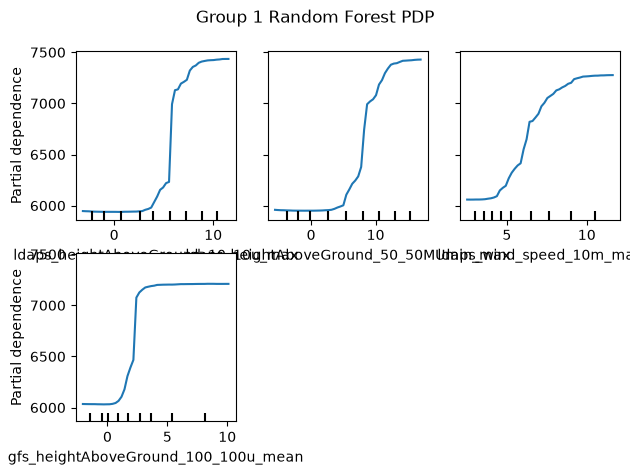

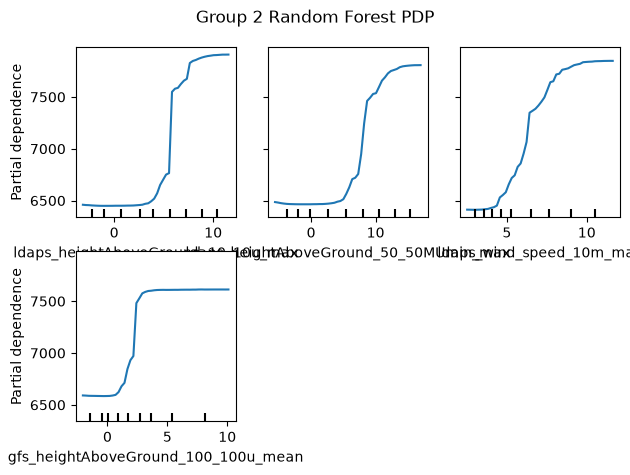

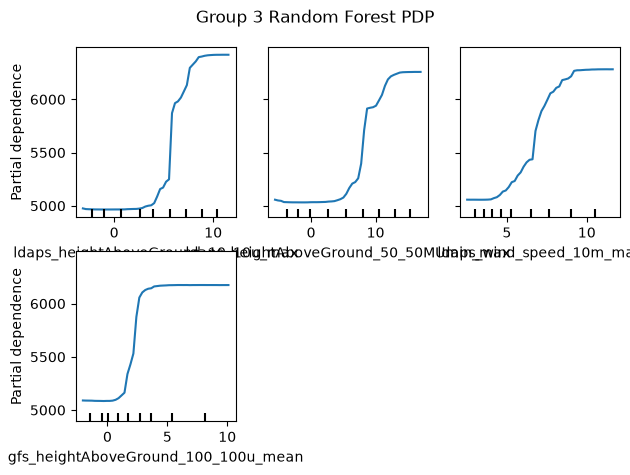

In [57]:
# PDP를 확인할 주요 피처 선정
pdp_features = [
    "ldaps_heightAboveGround_10_10u_max",
    "ldaps_heightAboveGround_50_50MUmin_max",
    "ldaps_wind_speed_10m_max",
    "gfs_heightAboveGround_100_100u_mean",
]

# Group 1 PDP
PartialDependenceDisplay.from_estimator(
    rf_1,
    X_valid_1_rf,
    features=pdp_features,
    kind="average",
    grid_resolution=50,
)

plt.suptitle("Group 1 Random Forest PDP")
plt.tight_layout()
plt.show()

# Group 2 PDP
PartialDependenceDisplay.from_estimator(
    rf_2,
    X_valid_2_rf,
    features=pdp_features,
    kind="average",
    grid_resolution=50,
)

plt.suptitle("Group 2 Random Forest PDP")
plt.tight_layout()
plt.show()

# Group 3 PDP
PartialDependenceDisplay.from_estimator(
    rf_3,
    X_valid_3_rf,
    features=pdp_features,
    kind="average",
    grid_resolution=50,
)

plt.suptitle("Group 3 Random Forest PDP")
plt.tight_layout()
plt.show()

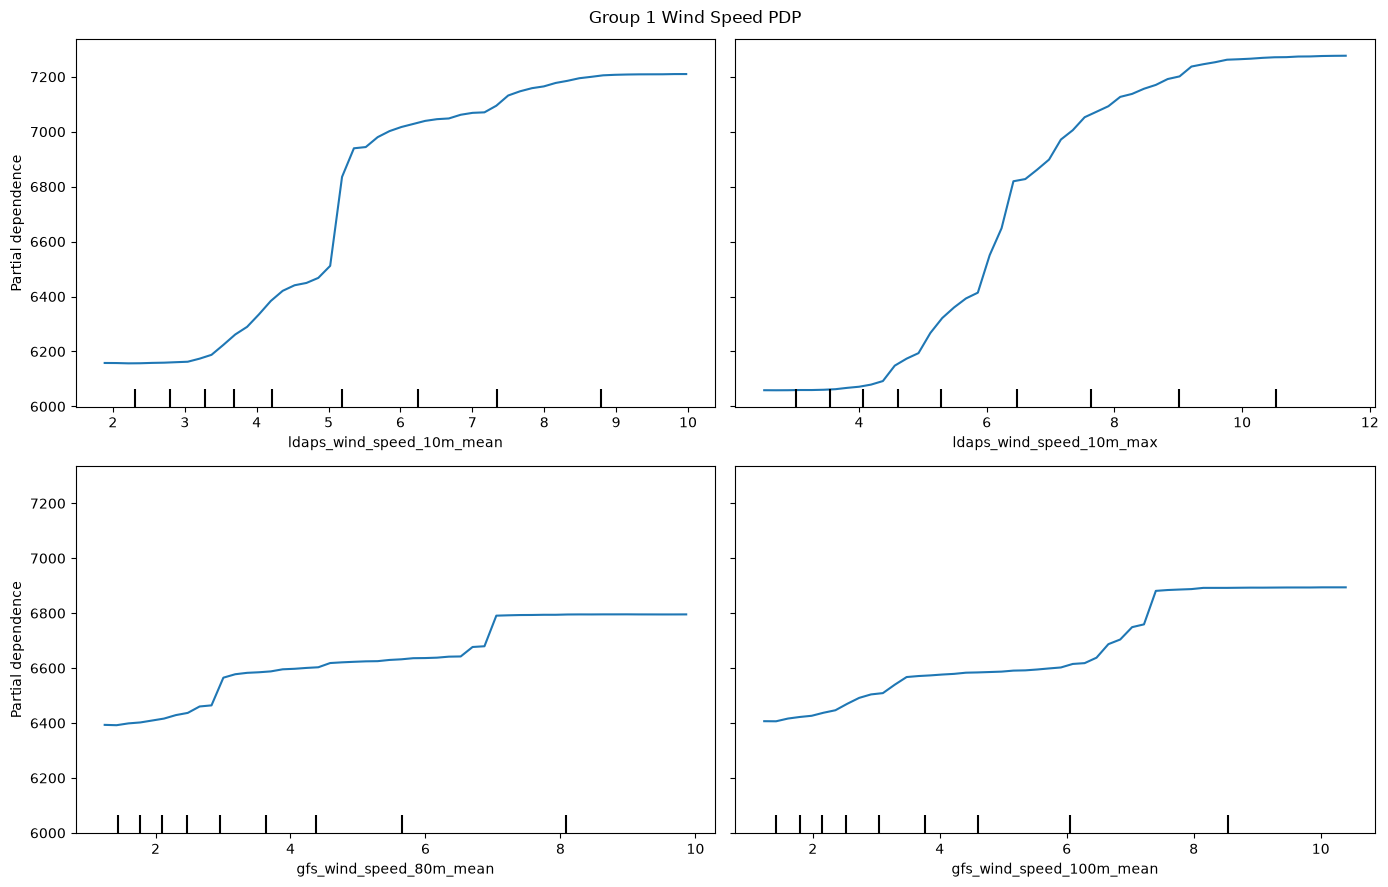

In [59]:
fig, ax = plt.subplots(
    2,
    2,
    figsize=(14, 9)
)

PartialDependenceDisplay.from_estimator(
    rf_1,
    X_valid_1_rf,
    features=pdp_wind_speed_features,
    kind="average",
    grid_resolution=50,
    ax=ax
)

plt.suptitle("Group 1 Wind Speed PDP")
plt.tight_layout()
plt.show()

- `ldaps_wind_speed_10m_mean` 
    - 약 3m/s 이하에서는 변화가 거의 없음
    - 3~5m/s 구간에서 증가
    - 5m/s 부근에서 큰 점프
    - 8~9m/s 이후 포화

- `ldaps_wind_speed_10m_max`
    - 가장 전형적인 S자 형태
    - 4~8m/s 구간에서 크게 증가
    - 9~10m/s 이후 포화

- `gfs_wind_speed_80m_mean`
    - 전체적으로 증가 방향은 맞음
    - 다만 변화폭이 LDAPS보다 작고 계단형
    - 중간 구간 정보력이 약하거나 다른 상관 피처가 대신 설명하는 것으로 보임

- `gfs_wind_speed_100m_mean`
    - 2~4m/s, 6~8m/s 부근에서 상승
    - 약 8m/s 이후 포화

> 결론 : Random Forest가 풍속 증가에 따라 발전량이 증가하고, 고풍속 구간에서 포화되는 풍력발전의 비선형 구조를 학습

## 2. Linear regressor BASELINE : Ridge Regression

- 현재 피처끼리 상관관계가 강해서, 일반 회귀는 계수가 크게 흔들릴 가능성이 높다. 
- Ridge는 계수를 안정화하면서 “선형 모델로 어디까지 설명 가능한지” 확인하는 용도

In [61]:
# 시간 원본 컬럼 제외
ridge_feature_cols = [
    col for col in feature_cols
    if col != "forecast_kst_dtm"
]

X_train_1_ridge = X_train_1[ridge_feature_cols]
X_valid_1_ridge = X_valid_1[ridge_feature_cols]

X_train_2_ridge = X_train_2[ridge_feature_cols]
X_valid_2_ridge = X_valid_2[ridge_feature_cols]

X_train_3_ridge = X_train_3[ridge_feature_cols]
X_valid_3_ridge = X_valid_3[ridge_feature_cols]

# Ridge 모델 구성
ridge_1 = make_pipeline(
    StandardScaler(),
    Ridge(alpha=10.0)
)

ridge_2 = make_pipeline(
    StandardScaler(),
    Ridge(alpha=10.0)
)

ridge_3 = make_pipeline(
    StandardScaler(),
    Ridge(alpha=10.0)
)

# 모델 학습
ridge_1.fit(X_train_1_ridge, y_train_1)
ridge_2.fit(X_train_2_ridge, y_train_2)
ridge_3.fit(X_train_3_ridge, y_train_3)

# 검증 데이터 예측
pred_ridge_1 = ridge_1.predict(X_valid_1_ridge)
pred_ridge_2 = ridge_2.predict(X_valid_2_ridge)
pred_ridge_3 = ridge_3.predict(X_valid_3_ridge)

# 발전량 범위 제한
pred_ridge_1 = np.clip(pred_ridge_1, 0, 21600)
pred_ridge_2 = np.clip(pred_ridge_2, 0, 21600)
pred_ridge_3 = np.clip(pred_ridge_3, 0, 21000)

# 평가 지표 계산
ridge_rmse_1 = mean_squared_error(
    y_valid_1,
    pred_ridge_1
) ** 0.5

ridge_rmse_2 = mean_squared_error(
    y_valid_2,
    pred_ridge_2
) ** 0.5

ridge_rmse_3 = mean_squared_error(
    y_valid_3,
    pred_ridge_3
) ** 0.5

ridge_mae_1 = mean_absolute_error(
    y_valid_1,
    pred_ridge_1
)

ridge_mae_2 = mean_absolute_error(
    y_valid_2,
    pred_ridge_2
)

ridge_mae_3 = mean_absolute_error(
    y_valid_3,
    pred_ridge_3
)

ridge_r2_1 = r2_score(
    y_valid_1,
    pred_ridge_1
)

ridge_r2_2 = r2_score(
    y_valid_2,
    pred_ridge_2
)

ridge_r2_3 = r2_score(
    y_valid_3,
    pred_ridge_3
)

# 결과 출력
print("Group 1 Ridge")
print("RMSE:", ridge_rmse_1)
print("MAE:", ridge_mae_1)
print("R2:", ridge_r2_1)

print("\nGroup 2 Ridge")
print("RMSE:", ridge_rmse_2)
print("MAE:", ridge_mae_2)
print("R2:", ridge_r2_2)

print("\nGroup 3 Ridge")
print("RMSE:", ridge_rmse_3)
print("MAE:", ridge_mae_3)
print("R2:", ridge_r2_3)

print(
    "\n평균 RMSE:",
    np.mean([
        ridge_rmse_1,
        ridge_rmse_2,
        ridge_rmse_3,
    ])
)

print(
    "평균 MAE:",
    np.mean([
        ridge_mae_1,
        ridge_mae_2,
        ridge_mae_3,
    ])
)

print(
    "평균 R2:",
    np.mean([
        ridge_r2_1,
        ridge_r2_2,
        ridge_r2_3,
    ])
)

Group 1 Ridge
RMSE: 3176.1328873587167
MAE: 2459.391058938254
R2: 0.8040042857639979

Group 2 Ridge
RMSE: 3465.0616359896776
MAE: 2601.166201680923
R2: 0.7948095612459731

Group 3 Ridge
RMSE: 3012.3296560756735
MAE: 2148.430058597741
R2: 0.7794711168242234

평균 RMSE: 3217.841393141356
평균 MAE: 2402.995773072306
평균 R2: 0.7927616546113981


## 3. Gradient Boosting BASELINE : LightGBM, XGBoost

In [63]:
# XGBoost 모델 정의
xgb_1 = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="rmse",
    early_stopping_rounds=100,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_2 = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="rmse",
    early_stopping_rounds=100,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_3 = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="rmse",
    early_stopping_rounds=100,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

# 모델 학습
xgb_1.fit(
    X_train_1_rf,
    y_train_1,
    eval_set=[(X_valid_1_rf, y_valid_1)],
    verbose=False
)

xgb_2.fit(
    X_train_2_rf,
    y_train_2,
    eval_set=[(X_valid_2_rf, y_valid_2)],
    verbose=False
)

xgb_3.fit(
    X_train_3_rf,
    y_train_3,
    eval_set=[(X_valid_3_rf, y_valid_3)],
    verbose=False
)

# 검증 데이터 예측
pred_xgb_1 = xgb_1.predict(X_valid_1_rf)
pred_xgb_2 = xgb_2.predict(X_valid_2_rf)
pred_xgb_3 = xgb_3.predict(X_valid_3_rf)

# 발전량 범위 제한
pred_xgb_1 = np.clip(pred_xgb_1, 0, 21600)
pred_xgb_2 = np.clip(pred_xgb_2, 0, 21600)
pred_xgb_3 = np.clip(pred_xgb_3, 0, 21000)

# 평가 지표 계산
xgb_rmse_1 = mean_squared_error(
    y_valid_1,
    pred_xgb_1
) ** 0.5

xgb_rmse_2 = mean_squared_error(
    y_valid_2,
    pred_xgb_2
) ** 0.5

xgb_rmse_3 = mean_squared_error(
    y_valid_3,
    pred_xgb_3
) ** 0.5

xgb_mae_1 = mean_absolute_error(
    y_valid_1,
    pred_xgb_1
)

xgb_mae_2 = mean_absolute_error(
    y_valid_2,
    pred_xgb_2
)

xgb_mae_3 = mean_absolute_error(
    y_valid_3,
    pred_xgb_3
)

xgb_r2_1 = r2_score(
    y_valid_1,
    pred_xgb_1
)

xgb_r2_2 = r2_score(
    y_valid_2,
    pred_xgb_2
)

xgb_r2_3 = r2_score(
    y_valid_3,
    pred_xgb_3
)

# 결과 출력
print("Group 1 XGBoost")
print("Best iteration:", xgb_1.best_iteration)
print("RMSE:", xgb_rmse_1)
print("MAE:", xgb_mae_1)
print("R2:", xgb_r2_1)

print("\nGroup 2 XGBoost")
print("Best iteration:", xgb_2.best_iteration)
print("RMSE:", xgb_rmse_2)
print("MAE:", xgb_mae_2)
print("R2:", xgb_r2_2)

print("\nGroup 3 XGBoost")
print("Best iteration:", xgb_3.best_iteration)
print("RMSE:", xgb_rmse_3)
print("MAE:", xgb_mae_3)
print("R2:", xgb_r2_3)

print(
    "\n평균 RMSE:",
    np.mean([
        xgb_rmse_1,
        xgb_rmse_2,
        xgb_rmse_3
    ])
)

print(
    "평균 MAE:",
    np.mean([
        xgb_mae_1,
        xgb_mae_2,
        xgb_mae_3
    ])
)

print(
    "평균 R2:",
    np.mean([
        xgb_r2_1,
        xgb_r2_2,
        xgb_r2_3
    ])
)

# 기존 모델과 성능 비교
model_comparison = pd.DataFrame({
    "model": [
        "Ridge",
        "Random Forest",
        "XGBoost"
    ],
    "mean_rmse": [
        np.mean([
            ridge_rmse_1,
            ridge_rmse_2,
            ridge_rmse_3
        ]),
        np.mean([
            rmse_1,
            rmse_2,
            rmse_3
        ]),
        np.mean([
            xgb_rmse_1,
            xgb_rmse_2,
            xgb_rmse_3
        ])
    ],
    "mean_mae": [
        np.mean([
            ridge_mae_1,
            ridge_mae_2,
            ridge_mae_3
        ]),
        np.mean([
            mae_1,
            mae_2,
            mae_3
        ]),
        np.mean([
            xgb_mae_1,
            xgb_mae_2,
            xgb_mae_3
        ])
    ],
    "mean_r2": [
        np.mean([
            ridge_r2_1,
            ridge_r2_2,
            ridge_r2_3
        ]),
        np.mean([
            r2_1,
            r2_2,
            r2_3
        ]),
        np.mean([
            xgb_r2_1,
            xgb_r2_2,
            xgb_r2_3
        ])
    ]
})

print("\n모델 성능 비교")
print(
    model_comparison.sort_values(
        "mean_rmse"
    ).reset_index(drop=True)
)

Group 1 XGBoost
Best iteration: 322
RMSE: 2739.4701530519405
MAE: 1970.5411960153442
R2: 0.8541916512758287

Group 2 XGBoost
Best iteration: 168
RMSE: 3062.8981715671525
MAE: 2213.7568648751576
R2: 0.8396753468844966

Group 3 XGBoost
Best iteration: 111
RMSE: 2816.1193202343393
MAE: 1917.7339676392046
R2: 0.8072641127209597

평균 RMSE: 2872.829214951144
평균 MAE: 2034.010676176569
평균 R2: 0.8337103702937617

모델 성능 비교
           model    mean_rmse     mean_mae   mean_r2
0        XGBoost  2872.829215  2034.010676  0.833710
1  Random Forest  2877.888850  2075.381021  0.833137
2          Ridge  3217.841393  2402.995773  0.792762


LightGBM 추가 시도

In [65]:
# LightGBM 모델 정의
lgbm_1 = LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_2 = LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_3 = LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# 모델 학습
lgbm_1.fit(
    X_train_1_rf,
    y_train_1,
    eval_set=[(X_valid_1_rf, y_valid_1)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            verbose=False
        )
    ]
)

lgbm_2.fit(
    X_train_2_rf,
    y_train_2,
    eval_set=[(X_valid_2_rf, y_valid_2)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            verbose=False
        )
    ]
)

lgbm_3.fit(
    X_train_3_rf,
    y_train_3,
    eval_set=[(X_valid_3_rf, y_valid_3)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            verbose=False
        )
    ]
)

# 검증 데이터 예측
pred_lgbm_1 = lgbm_1.predict(
    X_valid_1_rf,
    num_iteration=lgbm_1.best_iteration_
)

pred_lgbm_2 = lgbm_2.predict(
    X_valid_2_rf,
    num_iteration=lgbm_2.best_iteration_
)

pred_lgbm_3 = lgbm_3.predict(
    X_valid_3_rf,
    num_iteration=lgbm_3.best_iteration_
)

# 발전량 범위 제한
pred_lgbm_1 = np.clip(
    pred_lgbm_1,
    0,
    21600
)

pred_lgbm_2 = np.clip(
    pred_lgbm_2,
    0,
    21600
)

pred_lgbm_3 = np.clip(
    pred_lgbm_3,
    0,
    21000
)

# 평가 지표 계산
lgbm_rmse_1 = mean_squared_error(
    y_valid_1,
    pred_lgbm_1
) ** 0.5

lgbm_rmse_2 = mean_squared_error(
    y_valid_2,
    pred_lgbm_2
) ** 0.5

lgbm_rmse_3 = mean_squared_error(
    y_valid_3,
    pred_lgbm_3
) ** 0.5

lgbm_mae_1 = mean_absolute_error(
    y_valid_1,
    pred_lgbm_1
)

lgbm_mae_2 = mean_absolute_error(
    y_valid_2,
    pred_lgbm_2
)

lgbm_mae_3 = mean_absolute_error(
    y_valid_3,
    pred_lgbm_3
)

lgbm_r2_1 = r2_score(
    y_valid_1,
    pred_lgbm_1
)

lgbm_r2_2 = r2_score(
    y_valid_2,
    pred_lgbm_2
)

lgbm_r2_3 = r2_score(
    y_valid_3,
    pred_lgbm_3
)

# LightGBM 결과 출력
print("Group 1 LightGBM")
print("Best iteration:", lgbm_1.best_iteration_)
print("RMSE:", lgbm_rmse_1)
print("MAE:", lgbm_mae_1)
print("R2:", lgbm_r2_1)

print("\nGroup 2 LightGBM")
print("Best iteration:", lgbm_2.best_iteration_)
print("RMSE:", lgbm_rmse_2)
print("MAE:", lgbm_mae_2)
print("R2:", lgbm_r2_2)

print("\nGroup 3 LightGBM")
print("Best iteration:", lgbm_3.best_iteration_)
print("RMSE:", lgbm_rmse_3)
print("MAE:", lgbm_mae_3)
print("R2:", lgbm_r2_3)

print(
    "\nLightGBM 평균 RMSE:",
    np.mean([
        lgbm_rmse_1,
        lgbm_rmse_2,
        lgbm_rmse_3
    ])
)

print(
    "LightGBM 평균 MAE:",
    np.mean([
        lgbm_mae_1,
        lgbm_mae_2,
        lgbm_mae_3
    ])
)

print(
    "LightGBM 평균 R2:",
    np.mean([
        lgbm_r2_1,
        lgbm_r2_2,
        lgbm_r2_3
    ])
)

# 그룹별 모델 성능 비교
group_model_comparison = pd.DataFrame({
    "model": [
        "Ridge",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "group_1_rmse": [
        ridge_rmse_1,
        rmse_1,
        xgb_rmse_1,
        lgbm_rmse_1
    ],
    "group_2_rmse": [
        ridge_rmse_2,
        rmse_2,
        xgb_rmse_2,
        lgbm_rmse_2
    ],
    "group_3_rmse": [
        ridge_rmse_3,
        rmse_3,
        xgb_rmse_3,
        lgbm_rmse_3
    ],
    "group_1_mae": [
        ridge_mae_1,
        mae_1,
        xgb_mae_1,
        lgbm_mae_1
    ],
    "group_2_mae": [
        ridge_mae_2,
        mae_2,
        xgb_mae_2,
        lgbm_mae_2
    ],
    "group_3_mae": [
        ridge_mae_3,
        mae_3,
        xgb_mae_3,
        lgbm_mae_3
    ],
    "group_1_r2": [
        ridge_r2_1,
        r2_1,
        xgb_r2_1,
        lgbm_r2_1
    ],
    "group_2_r2": [
        ridge_r2_2,
        r2_2,
        xgb_r2_2,
        lgbm_r2_2
    ],
    "group_3_r2": [
        ridge_r2_3,
        r2_3,
        xgb_r2_3,
        lgbm_r2_3
    ]
})

# 평균 성능 계산
group_model_comparison["mean_rmse"] = (
    group_model_comparison[
        [
            "group_1_rmse",
            "group_2_rmse",
            "group_3_rmse"
        ]
    ].mean(axis=1)
)

group_model_comparison["mean_mae"] = (
    group_model_comparison[
        [
            "group_1_mae",
            "group_2_mae",
            "group_3_mae"
        ]
    ].mean(axis=1)
)

group_model_comparison["mean_r2"] = (
    group_model_comparison[
        [
            "group_1_r2",
            "group_2_r2",
            "group_3_r2"
        ]
    ].mean(axis=1)
)

# 평균 성능 비교
model_comparison = (
    group_model_comparison[
        [
            "model",
            "mean_rmse",
            "mean_mae",
            "mean_r2"
        ]
    ]
    .sort_values("mean_rmse")
    .reset_index(drop=True)
)

print("\n4개 모델 평균 성능 비교")
print(model_comparison)

print("\n그룹별 RMSE 비교")
print(
    group_model_comparison[
        [
            "model",
            "group_1_rmse",
            "group_2_rmse",
            "group_3_rmse"
        ]
    ]
    .sort_values("group_1_rmse")
    .reset_index(drop=True)
)

Group 1 LightGBM
Best iteration: 318
RMSE: 2753.37431130255
MAE: 1983.731803733076
R2: 0.8527077970112454

Group 2 LightGBM
Best iteration: 154
RMSE: 3065.084193010348
MAE: 2230.1728459196192
R2: 0.8394464145608898

Group 3 LightGBM
Best iteration: 121
RMSE: 2759.2334455109362
MAE: 1896.1580205877174
R2: 0.8149720340830555

LightGBM 평균 RMSE: 2859.2306499412775
LightGBM 평균 MAE: 2036.6875567468041
LightGBM 평균 R2: 0.8357087485517303

4개 모델 평균 성능 비교
           model    mean_rmse     mean_mae   mean_r2
0       LightGBM  2859.230650  2036.687557  0.835709
1        XGBoost  2872.829215  2034.010676  0.833710
2  Random Forest  2877.888850  2075.381021  0.833137
3          Ridge  3217.841393  2402.995773  0.792762

그룹별 RMSE 비교
           model  group_1_rmse  group_2_rmse  group_3_rmse
0        XGBoost   2739.470153   3062.898172   2816.119320
1       LightGBM   2753.374311   3065.084193   2759.233446
2  Random Forest   2812.499173   3009.749891   2811.417487
3          Ridge   3176.132887   346

## 4. Ensemble

In [67]:
# 단순 평균 앙상블
pred_ensemble_mean_1 = (
    pred_valid_1
    + pred_xgb_1
    + pred_lgbm_1
) / 3

pred_ensemble_mean_2 = (
    pred_valid_2
    + pred_xgb_2
    + pred_lgbm_2
) / 3

pred_ensemble_mean_3 = (
    pred_valid_3
    + pred_xgb_3
    + pred_lgbm_3
) / 3

# 발전량 범위 제한
pred_ensemble_mean_1 = np.clip(
    pred_ensemble_mean_1,
    0,
    21600
)

pred_ensemble_mean_2 = np.clip(
    pred_ensemble_mean_2,
    0,
    21600
)

pred_ensemble_mean_3 = np.clip(
    pred_ensemble_mean_3,
    0,
    21000
)

# 가중 평균 앙상블
# 그룹별 단일 모델 성능을 반영한 초기 가중치
pred_ensemble_weighted_1 = (
    0.20 * pred_valid_1
    + 0.50 * pred_xgb_1
    + 0.30 * pred_lgbm_1
)

pred_ensemble_weighted_2 = (
    0.50 * pred_valid_2
    + 0.25 * pred_xgb_2
    + 0.25 * pred_lgbm_2
)

pred_ensemble_weighted_3 = (
    0.20 * pred_valid_3
    + 0.20 * pred_xgb_3
    + 0.60 * pred_lgbm_3
)

# 발전량 범위 제한
pred_ensemble_weighted_1 = np.clip(
    pred_ensemble_weighted_1,
    0,
    21600
)

pred_ensemble_weighted_2 = np.clip(
    pred_ensemble_weighted_2,
    0,
    21600
)

pred_ensemble_weighted_3 = np.clip(
    pred_ensemble_weighted_3,
    0,
    21000
)

# 단순 평균 앙상블 평가
ensemble_mean_rmse_1 = mean_squared_error(
    y_valid_1,
    pred_ensemble_mean_1
) ** 0.5

ensemble_mean_rmse_2 = mean_squared_error(
    y_valid_2,
    pred_ensemble_mean_2
) ** 0.5

ensemble_mean_rmse_3 = mean_squared_error(
    y_valid_3,
    pred_ensemble_mean_3
) ** 0.5

ensemble_mean_mae_1 = mean_absolute_error(
    y_valid_1,
    pred_ensemble_mean_1
)

ensemble_mean_mae_2 = mean_absolute_error(
    y_valid_2,
    pred_ensemble_mean_2
)

ensemble_mean_mae_3 = mean_absolute_error(
    y_valid_3,
    pred_ensemble_mean_3
)

ensemble_mean_r2_1 = r2_score(
    y_valid_1,
    pred_ensemble_mean_1
)

ensemble_mean_r2_2 = r2_score(
    y_valid_2,
    pred_ensemble_mean_2
)

ensemble_mean_r2_3 = r2_score(
    y_valid_3,
    pred_ensemble_mean_3
)

# 가중 평균 앙상블 평가
ensemble_weighted_rmse_1 = mean_squared_error(
    y_valid_1,
    pred_ensemble_weighted_1
) ** 0.5

ensemble_weighted_rmse_2 = mean_squared_error(
    y_valid_2,
    pred_ensemble_weighted_2
) ** 0.5

ensemble_weighted_rmse_3 = mean_squared_error(
    y_valid_3,
    pred_ensemble_weighted_3
) ** 0.5

ensemble_weighted_mae_1 = mean_absolute_error(
    y_valid_1,
    pred_ensemble_weighted_1
)

ensemble_weighted_mae_2 = mean_absolute_error(
    y_valid_2,
    pred_ensemble_weighted_2
)

ensemble_weighted_mae_3 = mean_absolute_error(
    y_valid_3,
    pred_ensemble_weighted_3
)

ensemble_weighted_r2_1 = r2_score(
    y_valid_1,
    pred_ensemble_weighted_1
)

ensemble_weighted_r2_2 = r2_score(
    y_valid_2,
    pred_ensemble_weighted_2
)

ensemble_weighted_r2_3 = r2_score(
    y_valid_3,
    pred_ensemble_weighted_3
)

# 전체 모델 비교
ensemble_comparison = pd.DataFrame({
    "model": [
        "Ridge",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Ensemble Mean",
        "Ensemble Weighted"
    ],
    "group_1_rmse": [
        ridge_rmse_1,
        rmse_1,
        xgb_rmse_1,
        lgbm_rmse_1,
        ensemble_mean_rmse_1,
        ensemble_weighted_rmse_1
    ],
    "group_2_rmse": [
        ridge_rmse_2,
        rmse_2,
        xgb_rmse_2,
        lgbm_rmse_2,
        ensemble_mean_rmse_2,
        ensemble_weighted_rmse_2
    ],
    "group_3_rmse": [
        ridge_rmse_3,
        rmse_3,
        xgb_rmse_3,
        lgbm_rmse_3,
        ensemble_mean_rmse_3,
        ensemble_weighted_rmse_3
    ],
    "group_1_mae": [
        ridge_mae_1,
        mae_1,
        xgb_mae_1,
        lgbm_mae_1,
        ensemble_mean_mae_1,
        ensemble_weighted_mae_1
    ],
    "group_2_mae": [
        ridge_mae_2,
        mae_2,
        xgb_mae_2,
        lgbm_mae_2,
        ensemble_mean_mae_2,
        ensemble_weighted_mae_2
    ],
    "group_3_mae": [
        ridge_mae_3,
        mae_3,
        xgb_mae_3,
        lgbm_mae_3,
        ensemble_mean_mae_3,
        ensemble_weighted_mae_3
    ],
    "group_1_r2": [
        ridge_r2_1,
        r2_1,
        xgb_r2_1,
        lgbm_r2_1,
        ensemble_mean_r2_1,
        ensemble_weighted_r2_1
    ],
    "group_2_r2": [
        ridge_r2_2,
        r2_2,
        xgb_r2_2,
        lgbm_r2_2,
        ensemble_mean_r2_2,
        ensemble_weighted_r2_2
    ],
    "group_3_r2": [
        ridge_r2_3,
        r2_3,
        xgb_r2_3,
        lgbm_r2_3,
        ensemble_mean_r2_3,
        ensemble_weighted_r2_3
    ]
})

# 평균 지표 계산
ensemble_comparison["mean_rmse"] = (
    ensemble_comparison[
        [
            "group_1_rmse",
            "group_2_rmse",
            "group_3_rmse"
        ]
    ].mean(axis=1)
)

ensemble_comparison["mean_mae"] = (
    ensemble_comparison[
        [
            "group_1_mae",
            "group_2_mae",
            "group_3_mae"
        ]
    ].mean(axis=1)
)

ensemble_comparison["mean_r2"] = (
    ensemble_comparison[
        [
            "group_1_r2",
            "group_2_r2",
            "group_3_r2"
        ]
    ].mean(axis=1)
)

# 평균 성능 비교
print("전체 평균 성능 비교")
print(
    ensemble_comparison[
        [
            "model",
            "mean_rmse",
            "mean_mae",
            "mean_r2"
        ]
    ]
    .sort_values("mean_rmse")
    .reset_index(drop=True)
)

전체 평균 성능 비교
               model    mean_rmse     mean_mae   mean_r2
0  Ensemble Weighted  2831.036449  2025.383224  0.838601
1      Ensemble Mean  2838.926073  2030.926773  0.837675
2           LightGBM  2859.230650  2036.687557  0.835709
3            XGBoost  2872.829215  2034.010676  0.833710
4      Random Forest  2877.888850  2075.381021  0.833137
5              Ridge  3217.841393  2402.995773  0.792762


앙상블 가중치 조합 선택

In [69]:
# 앙상블 가중치 자동 탐색 함수
def find_best_ensemble_weights(
    y_true,
    pred_rf,
    pred_xgb,
    pred_lgbm,
    capacity,
    step=0.05
):
    results = []

    weights = np.arange(
        0,
        1 + step,
        step
    )

    for weight_rf in weights:
        for weight_xgb in weights:
            weight_lgbm = 1 - weight_rf - weight_xgb

            if weight_lgbm < 0:
                continue

            ensemble_pred = (
                weight_rf * pred_rf
                + weight_xgb * pred_xgb
                + weight_lgbm * pred_lgbm
            )

            ensemble_pred = np.clip(
                ensemble_pred,
                0,
                capacity
            )

            rmse = mean_squared_error(
                y_true,
                ensemble_pred
            ) ** 0.5

            mae = mean_absolute_error(
                y_true,
                ensemble_pred
            )

            r2 = r2_score(
                y_true,
                ensemble_pred
            )

            results.append({
                "weight_rf": weight_rf,
                "weight_xgb": weight_xgb,
                "weight_lgbm": weight_lgbm,
                "rmse": rmse,
                "mae": mae,
                "r2": r2
            })

    results = (
        pd.DataFrame(results)
        .sort_values("rmse")
        .reset_index(drop=True)
    )

    best_result = results.iloc[0]

    best_pred = (
        best_result["weight_rf"] * pred_rf
        + best_result["weight_xgb"] * pred_xgb
        + best_result["weight_lgbm"] * pred_lgbm
    )

    best_pred = np.clip(
        best_pred,
        0,
        capacity
    )

    return best_result, best_pred, results


# Group 1 최적 가중치 탐색
best_weight_1, pred_ensemble_opt_1, weight_results_1 = (
    find_best_ensemble_weights(
        y_valid_1,
        pred_valid_1,
        pred_xgb_1,
        pred_lgbm_1,
        capacity=21600,
        step=0.05
    )
)

# Group 2 최적 가중치 탐색
best_weight_2, pred_ensemble_opt_2, weight_results_2 = (
    find_best_ensemble_weights(
        y_valid_2,
        pred_valid_2,
        pred_xgb_2,
        pred_lgbm_2,
        capacity=21600,
        step=0.05
    )
)

# Group 3 최적 가중치 탐색
best_weight_3, pred_ensemble_opt_3, weight_results_3 = (
    find_best_ensemble_weights(
        y_valid_3,
        pred_valid_3,
        pred_xgb_3,
        pred_lgbm_3,
        capacity=21000,
        step=0.05
    )
)

# 최적 가중치 출력
print("Group 1 최적 가중치")
print(best_weight_1)

print("\nGroup 2 최적 가중치")
print(best_weight_2)

print("\nGroup 3 최적 가중치")
print(best_weight_3)


# 최적 앙상블 평가 지표
ensemble_opt_rmse_1 = mean_squared_error(
    y_valid_1,
    pred_ensemble_opt_1
) ** 0.5

ensemble_opt_rmse_2 = mean_squared_error(
    y_valid_2,
    pred_ensemble_opt_2
) ** 0.5

ensemble_opt_rmse_3 = mean_squared_error(
    y_valid_3,
    pred_ensemble_opt_3
) ** 0.5

ensemble_opt_mae_1 = mean_absolute_error(
    y_valid_1,
    pred_ensemble_opt_1
)

ensemble_opt_mae_2 = mean_absolute_error(
    y_valid_2,
    pred_ensemble_opt_2
)

ensemble_opt_mae_3 = mean_absolute_error(
    y_valid_3,
    pred_ensemble_opt_3
)

ensemble_opt_r2_1 = r2_score(
    y_valid_1,
    pred_ensemble_opt_1
)

ensemble_opt_r2_2 = r2_score(
    y_valid_2,
    pred_ensemble_opt_2
)

ensemble_opt_r2_3 = r2_score(
    y_valid_3,
    pred_ensemble_opt_3
)


# 기존 비교표에 최적 앙상블 추가
optimized_ensemble_result = pd.DataFrame({
    "model": [
        "Ensemble Optimized"
    ],
    "group_1_rmse": [
        ensemble_opt_rmse_1
    ],
    "group_2_rmse": [
        ensemble_opt_rmse_2
    ],
    "group_3_rmse": [
        ensemble_opt_rmse_3
    ],
    "group_1_mae": [
        ensemble_opt_mae_1
    ],
    "group_2_mae": [
        ensemble_opt_mae_2
    ],
    "group_3_mae": [
        ensemble_opt_mae_3
    ],
    "group_1_r2": [
        ensemble_opt_r2_1
    ],
    "group_2_r2": [
        ensemble_opt_r2_2
    ],
    "group_3_r2": [
        ensemble_opt_r2_3
    ]
})

optimized_ensemble_result["mean_rmse"] = (
    optimized_ensemble_result[
        [
            "group_1_rmse",
            "group_2_rmse",
            "group_3_rmse"
        ]
    ].mean(axis=1)
)

optimized_ensemble_result["mean_mae"] = (
    optimized_ensemble_result[
        [
            "group_1_mae",
            "group_2_mae",
            "group_3_mae"
        ]
    ].mean(axis=1)
)

optimized_ensemble_result["mean_r2"] = (
    optimized_ensemble_result[
        [
            "group_1_r2",
            "group_2_r2",
            "group_3_r2"
        ]
    ].mean(axis=1)
)

ensemble_comparison_final = pd.concat(
    [
        ensemble_comparison,
        optimized_ensemble_result
    ],
    ignore_index=True
)

# 최종 평균 성능 비교
print("\n최종 평균 성능 비교")

final_mean_comparison = (
    ensemble_comparison_final
    .sort_values("mean_rmse")
    .reset_index(drop=True)
)

print(
    final_mean_comparison[
        [
            "model",
            "mean_rmse",
            "mean_mae",
            "mean_r2"
        ]
    ]
)

# 최종 그룹별 RMSE 비교
print("\n최종 그룹별 RMSE 비교")

final_group_rmse_comparison = (
    ensemble_comparison_final
    .sort_values("mean_rmse")
    .reset_index(drop=True)
)

print(
    final_group_rmse_comparison[
        [
            "model",
            "group_1_rmse",
            "group_2_rmse",
            "group_3_rmse",
            "mean_rmse"
        ]
    ]
)

Group 1 최적 가중치
weight_rf         0.200000
weight_xgb        0.500000
weight_lgbm       0.300000
rmse           2729.080664
mae            1981.665859
r2                0.855296
Name: 0, dtype: float64

Group 2 최적 가중치
weight_rf         0.700000
weight_xgb        0.000000
weight_lgbm       0.300000
rmse           2994.963605
mae            2201.024730
r2                0.846708
Name: 0, dtype: float64

Group 3 최적 가중치
weight_rf         0.150000
weight_xgb        0.000000
weight_lgbm       0.850000
rmse           2756.976098
mae            1894.032095
r2                0.815275
Name: 0, dtype: float64

최종 평균 성능 비교
                model    mean_rmse     mean_mae   mean_r2
0  Ensemble Optimized  2827.006789  2025.574228  0.839093
1   Ensemble Weighted  2831.036449  2025.383224  0.838601
2       Ensemble Mean  2838.926073  2030.926773  0.837675
3            LightGBM  2859.230650  2036.687557  0.835709
4             XGBoost  2872.829215  2034.010676  0.833710
5       Random Forest  2877.888850

시계열 교차검증

In [70]:
# 시계열 교차검증 구간 설정
cv_folds = [
    {
        "fold": 1,
        "valid_start": pd.Timestamp("2024-04-01 01:00:00"),
        "valid_end": pd.Timestamp("2024-07-01 01:00:00"),
    },
    {
        "fold": 2,
        "valid_start": pd.Timestamp("2024-07-01 01:00:00"),
        "valid_end": pd.Timestamp("2024-10-01 01:00:00"),
    },
    {
        "fold": 3,
        "valid_start": pd.Timestamp("2024-10-01 01:00:00"),
        "valid_end": pd.Timestamp("2025-01-01 01:00:00"),
    },
]


# 앙상블 가중치 탐색 함수
def find_best_cv_weights(
    y_true,
    pred_rf,
    pred_xgb,
    pred_lgbm,
    capacity,
    step=0.05,
):
    results = []

    weights = np.arange(
        0,
        1 + step,
        step,
    )

    for weight_rf in weights:
        for weight_xgb in weights:
            weight_lgbm = 1 - weight_rf - weight_xgb

            if weight_lgbm < -1e-9:
                continue

            weight_lgbm = max(
                0,
                weight_lgbm,
            )

            pred_ensemble = (
                weight_rf * pred_rf
                + weight_xgb * pred_xgb
                + weight_lgbm * pred_lgbm
            )

            pred_ensemble = np.clip(
                pred_ensemble,
                0,
                capacity,
            )

            rmse = mean_squared_error(
                y_true,
                pred_ensemble,
            ) ** 0.5

            results.append({
                "weight_rf": weight_rf,
                "weight_xgb": weight_xgb,
                "weight_lgbm": weight_lgbm,
                "rmse": rmse,
            })

    results = (
        pd.DataFrame(results)
        .sort_values("rmse")
        .reset_index(drop=True)
    )

    best = results.iloc[0]

    best_pred = (
        best["weight_rf"] * pred_rf
        + best["weight_xgb"] * pred_xgb
        + best["weight_lgbm"] * pred_lgbm
    )

    best_pred = np.clip(
        best_pred,
        0,
        capacity,
    )

    return best, best_pred


# 그룹별 시계열 교차검증 함수
def run_group_time_cv(
    group_name,
    group_df,
    target_col,
    capacity,
):
    cv_results = []
    cv_weights = []

    for fold_info in cv_folds:
        fold_number = fold_info["fold"]
        valid_start = fold_info["valid_start"]
        valid_end = fold_info["valid_end"]

        train_mask = (
            group_df["forecast_kst_dtm"] < valid_start
        )

        valid_mask = (
            (group_df["forecast_kst_dtm"] >= valid_start)
            & (group_df["forecast_kst_dtm"] < valid_end)
        )

        fold_train = group_df.loc[
            train_mask
        ].copy()

        fold_valid = group_df.loc[
            valid_mask
        ].copy()

        X_fold_train = fold_train[
            model_feature_cols
        ]

        y_fold_train = fold_train[
            target_col
        ]

        X_fold_valid = fold_valid[
            model_feature_cols
        ]

        y_fold_valid = fold_valid[
            target_col
        ]

        # Random Forest
        rf_model = RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42,
        )

        rf_model.fit(
            X_fold_train,
            y_fold_train,
        )

        pred_rf = rf_model.predict(
            X_fold_valid
        )

        pred_rf = np.clip(
            pred_rf,
            0,
            capacity,
        )

        # XGBoost
        xgb_model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=3000,
            learning_rate=0.03,
            max_depth=6,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric="rmse",
            early_stopping_rounds=100,
            tree_method="hist",
            n_jobs=-1,
            random_state=42,
        )

        xgb_model.fit(
            X_fold_train,
            y_fold_train,
            eval_set=[
                (
                    X_fold_valid,
                    y_fold_valid,
                )
            ],
            verbose=False,
        )

        pred_xgb = xgb_model.predict(
            X_fold_valid
        )

        pred_xgb = np.clip(
            pred_xgb,
            0,
            capacity,
        )

        # LightGBM
        lgbm_model = LGBMRegressor(
            objective="regression",
            n_estimators=3000,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
        )

        lgbm_model.fit(
            X_fold_train,
            y_fold_train,
            eval_set=[
                (
                    X_fold_valid,
                    y_fold_valid,
                )
            ],
            eval_metric="rmse",
            callbacks=[
                early_stopping(
                    stopping_rounds=100,
                    verbose=False,
                )
            ],
        )

        pred_lgbm = lgbm_model.predict(
            X_fold_valid,
            num_iteration=lgbm_model.best_iteration_,
        )

        pred_lgbm = np.clip(
            pred_lgbm,
            0,
            capacity,
        )

        # 최적 앙상블 가중치 탐색
        best_weight, pred_ensemble = (
            find_best_cv_weights(
                y_fold_valid,
                pred_rf,
                pred_xgb,
                pred_lgbm,
                capacity=capacity,
                step=0.05,
            )
        )

        model_predictions = {
            "Random Forest": pred_rf,
            "XGBoost": pred_xgb,
            "LightGBM": pred_lgbm,
            "Ensemble Optimized": pred_ensemble,
        }

        for model_name, prediction in model_predictions.items():
            rmse = mean_squared_error(
                y_fold_valid,
                prediction,
            ) ** 0.5

            mae = mean_absolute_error(
                y_fold_valid,
                prediction,
            )

            r2 = r2_score(
                y_fold_valid,
                prediction,
            )

            cv_results.append({
                "group": group_name,
                "fold": fold_number,
                "model": model_name,
                "train_count": len(fold_train),
                "valid_count": len(fold_valid),
                "valid_start": valid_start,
                "valid_end": valid_end,
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
            })

        cv_weights.append({
            "group": group_name,
            "fold": fold_number,
            "weight_rf": best_weight["weight_rf"],
            "weight_xgb": best_weight["weight_xgb"],
            "weight_lgbm": best_weight["weight_lgbm"],
            "ensemble_rmse": best_weight["rmse"],
            "xgb_best_iteration": xgb_model.best_iteration,
            "lgbm_best_iteration": lgbm_model.best_iteration_,
        })

        print(
            group_name,
            "Fold",
            fold_number,
            "완료",
        )

        print(
            "Train:",
            len(fold_train),
            "Valid:",
            len(fold_valid),
        )

        print(
            "가중치:",
            f"RF {best_weight['weight_rf']:.2f},",
            f"XGB {best_weight['weight_xgb']:.2f},",
            f"LGBM {best_weight['weight_lgbm']:.2f}",
        )

        print(
            "Ensemble RMSE:",
            f"{best_weight['rmse']:.4f}",
        )

        print()

    return (
        pd.DataFrame(cv_results),
        pd.DataFrame(cv_weights),
    )


# Group 1 교차검증
cv_result_1, cv_weight_1 = run_group_time_cv(
    group_name="Group 1",
    group_df=train_group_1,
    target_col="kpx_group_1",
    capacity=21600,
)


# Group 2 교차검증
cv_result_2, cv_weight_2 = run_group_time_cv(
    group_name="Group 2",
    group_df=train_group_2,
    target_col="kpx_group_2",
    capacity=21600,
)


# Group 3 교차검증
cv_result_3, cv_weight_3 = run_group_time_cv(
    group_name="Group 3",
    group_df=train_group_3,
    target_col="kpx_group_3",
    capacity=21000,
)


# 세 그룹 결과 결합
cv_results = pd.concat(
    [
        cv_result_1,
        cv_result_2,
        cv_result_3,
    ],
    ignore_index=True,
)

cv_weights = pd.concat(
    [
        cv_weight_1,
        cv_weight_2,
        cv_weight_3,
    ],
    ignore_index=True,
)


# 그룹과 모델별 평균 성능
cv_group_summary = (
    cv_results
    .groupby(
        [
            "group",
            "model",
        ]
    )
    .agg(
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std"),
    )
    .reset_index()
    .sort_values(
        [
            "group",
            "mean_rmse",
        ]
    )
)

print("그룹별 교차검증 평균 성능")
print(cv_group_summary)


# 전체 그룹 평균 성능
cv_total_summary = (
    cv_results
    .groupby("model")
    .agg(
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std"),
    )
    .reset_index()
    .sort_values("mean_rmse")
)

print("\n전체 교차검증 평균 성능")
print(cv_total_summary)


# Fold별 최적 앙상블 가중치
print("\nFold별 최적 앙상블 가중치")
print(cv_weights)


# 그룹별 평균 앙상블 가중치
cv_weight_summary = (
    cv_weights
    .groupby("group")
    .agg(
        mean_weight_rf=("weight_rf", "mean"),
        std_weight_rf=("weight_rf", "std"),
        mean_weight_xgb=("weight_xgb", "mean"),
        std_weight_xgb=("weight_xgb", "std"),
        mean_weight_lgbm=("weight_lgbm", "mean"),
        std_weight_lgbm=("weight_lgbm", "std"),
        mean_ensemble_rmse=("ensemble_rmse", "mean"),
    )
    .reset_index()
)

print("\n그룹별 평균 앙상블 가중치")
print(cv_weight_summary)

Group 1 Fold 1 완료
Train: 19606 Valid: 2184
가중치: RF 0.25, XGB 0.40, LGBM 0.35
Ensemble RMSE: 2719.0475

Group 1 Fold 2 완료
Train: 21790 Valid: 2202
가중치: RF 0.25, XGB 0.50, LGBM 0.25
Ensemble RMSE: 2654.3475



/Users/chankyulee/Desktop/DACON_BARAM3/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/chankyulee/Desktop/DACON_BARAM3/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/chankyulee/Desktop/DACON_BARAM3/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

Group 1 Fold 3 완료
Train: 23992 Valid: 2208
가중치: RF 0.20, XGB 0.50, LGBM 0.30
Ensemble RMSE: 2729.0807



/Users/chankyulee/Desktop/DACON_BARAM3/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/chankyulee/Desktop/DACON_BARAM3/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/chankyulee/Desktop/DACON_BARAM3/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

Group 2 Fold 1 완료
Train: 19607 Valid: 2184
가중치: RF 0.15, XGB 0.40, LGBM 0.45
Ensemble RMSE: 2555.5791



/Users/chankyulee/Desktop/DACON_BARAM3/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/chankyulee/Desktop/DACON_BARAM3/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/chankyulee/Desktop/DACON_BARAM3/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

Group 2 Fold 2 완료
Train: 21791 Valid: 2202
가중치: RF 0.05, XGB 0.50, LGBM 0.45
Ensemble RMSE: 2395.6159

Group 2 Fold 3 완료
Train: 23993 Valid: 2208
가중치: RF 0.70, XGB 0.00, LGBM 0.30
Ensemble RMSE: 2994.9636

Group 3 Fold 1 완료
Train: 10944 Valid: 2184
가중치: RF 0.05, XGB 0.35, LGBM 0.60
Ensemble RMSE: 2769.3725

Group 3 Fold 2 완료
Train: 13128 Valid: 2202
가중치: RF 0.25, XGB 0.50, LGBM 0.25
Ensemble RMSE: 2710.6333

Group 3 Fold 3 완료
Train: 15330 Valid: 2208
가중치: RF 0.15, XGB 0.00, LGBM 0.85
Ensemble RMSE: 2756.9761

그룹별 교차검증 평균 성능
      group               model    mean_rmse    std_rmse     mean_mae  \
0   Group 1  Ensemble Optimized  2700.825231   40.562282  1873.136549   
3   Group 1             XGBoost  2714.674515   44.990461  1866.007293   
1   Group 1            LightGBM  2722.261930   40.050973  1880.136468   
2   Group 1       Random Forest  2757.592903   60.020930  1954.299381   
4   Group 2  Ensemble Optimized  2648.719538  310.339777  1857.608879   
7   Group 2             XGBoost 

In [ ]:
# 제출 파일 형식 확인
sample_submission = pd.read_csv(
    "/Users/chankyulee/Desktop/DACON_BARAM3/sample_submission.csv"
)

print(sample_submission.shape)
print(sample_submission.columns.tolist())
print(sample_submission.head())

(8760, 5)
['forecast_id', 'forecast_kst_dtm', 'kpx_group_1', 'kpx_group_2', 'kpx_group_3']
     forecast_id     forecast_kst_dtm  kpx_group_1  kpx_group_2  kpx_group_3
0  forecast_0001  2025-01-01 01:00:00            0            0            0
1  forecast_0002  2025-01-01 02:00:00            0            0            0
2  forecast_0003  2025-01-01 03:00:00            0            0            0
3  forecast_0004  2025-01-01 04:00:00            0            0            0
4  forecast_0005  2025-01-01 05:00:00            0            0            0


In [74]:
# 1. 교차검증 결과에서 그룹별 최종 반복 횟수 결정
final_iterations = (
    cv_weights
    .groupby("group")
    .agg(
        xgb_n_estimators=("xgb_best_iteration", "median"),
        lgbm_n_estimators=("lgbm_best_iteration", "median"),
    )
)

final_iterations["xgb_n_estimators"] = (
    final_iterations["xgb_n_estimators"]
    .round()
    .astype(int)
    + 1
)

final_iterations["lgbm_n_estimators"] = (
    final_iterations["lgbm_n_estimators"]
    .round()
    .astype(int)
)

print("최종 반복 횟수")
print(final_iterations)


# 2. 교차검증 기반 최종 앙상블 가중치
final_weights = {
    "Group 1": {
        "rf": 0.23,
        "xgb": 0.47,
        "lgbm": 0.30,
    },
    "Group 2": {
        "rf": 0.30,
        "xgb": 0.30,
        "lgbm": 0.40,
    },
    "Group 3": {
        "rf": 0.15,
        "xgb": 0.30,
        "lgbm": 0.55,
    },
}


# 3. 전체 데이터 학습 및 test 예측 함수
def train_final_ensemble(
    group_name,
    group_df,
    target_col,
    test_df,
    capacity,
):
    X_train_full = group_df[model_feature_cols]
    y_train_full = group_df[target_col]
    X_test_full = test_df[model_feature_cols]

    xgb_n_estimators = final_iterations.loc[
        group_name,
        "xgb_n_estimators",
    ]

    lgbm_n_estimators = final_iterations.loc[
        group_name,
        "lgbm_n_estimators",
    ]

    weights = final_weights[group_name]

    # Random Forest
    rf_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    )

    rf_model.fit(
        X_train_full,
        y_train_full,
    )

    pred_rf = rf_model.predict(
        X_test_full
    )

    # XGBoost
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=xgb_n_estimators,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )

    xgb_model.fit(
        X_train_full,
        y_train_full,
        verbose=False,
    )

    pred_xgb = xgb_model.predict(
        X_test_full
    )

    # LightGBM
    lgbm_model = LGBMRegressor(
        objective="regression",
        n_estimators=lgbm_n_estimators,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    lgbm_model.fit(
        X_train_full,
        y_train_full,
    )

    pred_lgbm = lgbm_model.predict(
        X_test_full
    )

    # 모델별 예측값 범위 제한
    pred_rf = np.clip(
        pred_rf,
        0,
        capacity,
    )

    pred_xgb = np.clip(
        pred_xgb,
        0,
        capacity,
    )

    pred_lgbm = np.clip(
        pred_lgbm,
        0,
        capacity,
    )

    # 최종 가중 앙상블
    pred_ensemble = (
        weights["rf"] * pred_rf
        + weights["xgb"] * pred_xgb
        + weights["lgbm"] * pred_lgbm
    )

    pred_ensemble = np.clip(
        pred_ensemble,
        0,
        capacity,
    )

    print(
        group_name,
        "학습 완료",
        "| XGB trees:",
        xgb_n_estimators,
        "| LGBM trees:",
        lgbm_n_estimators,
    )

    return {
        "rf_model": rf_model,
        "xgb_model": xgb_model,
        "lgbm_model": lgbm_model,
        "pred_rf": pred_rf,
        "pred_xgb": pred_xgb,
        "pred_lgbm": pred_lgbm,
        "pred_ensemble": pred_ensemble,
    }


# 4. 그룹별 전체 데이터 재학습 및 예측
final_result_1 = train_final_ensemble(
    group_name="Group 1",
    group_df=train_group_1,
    target_col="kpx_group_1",
    test_df=test,
    capacity=21600,
)

final_result_2 = train_final_ensemble(
    group_name="Group 2",
    group_df=train_group_2,
    target_col="kpx_group_2",
    test_df=test,
    capacity=21600,
)

final_result_3 = train_final_ensemble(
    group_name="Group 3",
    group_df=train_group_3,
    target_col="kpx_group_3",
    test_df=test,
    capacity=21000,
)


# 5. 샘플 제출 파일에 예측값 입력
submission = sample_submission.copy()

submission["kpx_group_1"] = final_result_1[
    "pred_ensemble"
]

submission["kpx_group_2"] = final_result_2[
    "pred_ensemble"
]

submission["kpx_group_3"] = final_result_3[
    "pred_ensemble"
]


# 6. 제출 데이터 검증
assert len(submission) == len(test)
assert submission[
    [
        "kpx_group_1",
        "kpx_group_2",
        "kpx_group_3",
    ]
].isna().sum().sum() == 0

assert (
    submission["forecast_kst_dtm"].astype(str).values
    == test["forecast_kst_dtm"].astype(str).values
).all()

print("\n제출 파일 shape:", submission.shape)

print("\n결측치")
print(submission.isna().sum())

print("\n예측값 통계")
print(
    submission[
        [
            "kpx_group_1",
            "kpx_group_2",
            "kpx_group_3",
        ]
    ].describe()
)

print("\n제출 파일 앞부분")
print(submission.head())


# 7. CSV 저장
submission_path = "submission_ensemble_cv.csv"

submission.to_csv(
    submission_path,
    index=False,
    encoding="utf-8-sig",
)

print("\n저장 완료:", submission_path)

최종 반복 횟수
         xgb_n_estimators  lgbm_n_estimators
group                                       
Group 1               323                272
Group 2               169                192
Group 3               208                175
Group 1 학습 완료 | XGB trees: 323 | LGBM trees: 272
Group 2 학습 완료 | XGB trees: 169 | LGBM trees: 192
Group 3 학습 완료 | XGB trees: 208 | LGBM trees: 175

제출 파일 shape: (8760, 5)

결측치
forecast_id         0
forecast_kst_dtm    0
kpx_group_1         0
kpx_group_2         0
kpx_group_3         0
dtype: int64

예측값 통계
        kpx_group_1   kpx_group_2   kpx_group_3
count   8760.000000   8760.000000   8760.000000
mean    7451.740361   7781.770011   6344.637318
std     5785.993906   5987.260073   5458.831563
min       14.182084     46.228990    115.376783
25%     1913.311134   1971.244114   1103.273094
50%     6374.067859   6744.001636   4873.620508
75%    12620.933714  13179.707820  11101.074073
max    20347.827192  19900.930918  19291.610951

제출 파일 앞부분
     forecast_id

In [76]:
# 시간 중복 여부
print("train 시간 중복:", train["forecast_kst_dtm"].duplicated().sum())
print("test 시간 중복:", test["forecast_kst_dtm"].duplicated().sum())

# 시간 정렬 여부
print(
    "train 시간 정렬:",
    train["forecast_kst_dtm"].is_monotonic_increasing
)
print(
    "test 시간 정렬:",
    test["forecast_kst_dtm"].is_monotonic_increasing
)

# feature 컬럼 일치 여부
print(
    "feature 컬럼 일치:",
    train[model_feature_cols].columns.tolist()
    == test[model_feature_cols].columns.tolist()
)

# 무한값 여부
print(
    "train inf:",
    np.isinf(train[model_feature_cols].to_numpy()).sum()
)
print(
    "test inf:",
    np.isinf(test[model_feature_cols].to_numpy()).sum()
)

# 그룹별 target 결측 여부
print("Group 1 target 결측:", train_group_1["kpx_group_1"].isna().sum())
print("Group 2 target 결측:", train_group_2["kpx_group_2"].isna().sum())
print("Group 3 target 결측:", train_group_3["kpx_group_3"].isna().sum())

train 시간 중복: 0
test 시간 중복: 0
train 시간 정렬: True
test 시간 정렬: True
feature 컬럼 일치: True
train inf: 0
test inf: 0
Group 1 target 결측: 0
Group 2 target 결측: 0
Group 3 target 결측: 0


In [77]:
train.to_parquet(
    "train_preprocessed.parquet",
    index=False
)

test.to_parquet(
    "test_preprocessed.parquet",
    index=False
)

pd.Series(
    model_feature_cols,
    name="feature"
).to_csv(
    "model_feature_cols.csv",
    index=False
)